<a href="https://www.kaggle.com/code/hisyamsyafaraditya/final-project-machine-learning?scriptVersionId=327631361" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Libraries

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings("ignore")

# Load Dataset

In [2]:
train_df = pd.read_csv("/kaggle/input/datasets/stealthtechnologies/employee-attrition-dataset/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/stealthtechnologies/employee-attrition-dataset/test.csv")

# Data Understanding

## Dataset Overview

### Training Set

In [3]:
display(train_df.head())

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [4]:
print("Train Dataset Information")
print(f"Jumlah baris : {train_df.shape[0]}")
print(f"Jumlah kolom : {train_df.shape[1]}")

Train Dataset Information
Jumlah baris : 59598
Jumlah kolom : 24


### Testing Set

In [5]:
display(test_df.head())

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


In [6]:
print("Test Dataset Information")
print(f"Jumlah baris : {test_df.shape[0]}")
print(f"Jumlah kolom : {test_df.shape[1]}")

Test Dataset Information
Jumlah baris : 14900
Jumlah kolom : 24


## Statistical Summary

### Training Set

In [7]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Employee ID,59598.0,37227.118729,21519.150028,1.0,18580.25,37209.5,55876.75,74498.0
Age,59598.0,38.565875,12.079673,18.0,28.00,39.0,49.00,59.0
Years at Company,59598.0,15.753901,11.245981,1.0,7.00,13.0,23.00,51.0
Monthly Income,59598.0,7302.397983,2151.457423,1316.0,5658.00,7354.0,8880.00,16149.0
Number of Promotions,59598.0,0.832578,0.994991,0.0,0.00,1.0,2.00,4.0
Distance from Home,59598.0,50.007651,28.466459,1.0,25.00,50.0,75.00,99.0
Number of Dependents,59598.0,1.648075,1.555689,0.0,0.00,1.0,3.00,6.0
Company Tenure,59598.0,55.758415,25.411090,2.0,36.00,56.0,76.00,128.0


### Testing Set

In [8]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Employee ID,14900.0,37339.022081,21453.129293,5.0,18825.50,37433.0,55857.5,74471.0
Age,14900.0,38.385235,12.097904,18.0,28.00,38.0,49.0,59.0
Years at Company,14900.0,15.592416,11.133792,1.0,7.00,13.0,23.0,51.0
Monthly Income,14900.0,7287.306040,2156.737934,1226.0,5633.75,7332.0,8852.0,15063.0
Number of Promotions,14900.0,0.834362,0.996511,0.0,0.00,1.0,2.0,4.0
Distance from Home,14900.0,49.927315,28.702307,1.0,25.00,50.0,75.0,99.0
Number of Dependents,14900.0,1.659329,1.545401,0.0,0.00,1.0,3.0,6.0
Company Tenure,14900.0,55.603624,25.352807,2.0,36.00,56.0,75.0,127.0


## Feature Types

### Training Set

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

### Testing Set

In [10]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               14900 non-null  int64 
 1   Age                       14900 non-null  int64 
 2   Gender                    14900 non-null  object
 3   Years at Company          14900 non-null  int64 
 4   Job Role                  14900 non-null  object
 5   Monthly Income            14900 non-null  int64 
 6   Work-Life Balance         14900 non-null  object
 7   Job Satisfaction          14900 non-null  object
 8   Performance Rating        14900 non-null  object
 9   Number of Promotions      14900 non-null  int64 
 10  Overtime                  14900 non-null  object
 11  Distance from Home        14900 non-null  int64 
 12  Education Level           14900 non-null  object
 13  Marital Status            14900 non-null  object
 14  Number of Dependents  

# Exploratory Data Analysis (EDA)

## Missing Value Check

In [11]:
print(train_df.isnull().sum())

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64


## Duplicate Check

In [12]:
print("Duplicate rows :", train_df.duplicated().sum())

Duplicate rows : 0


## Class Distribution

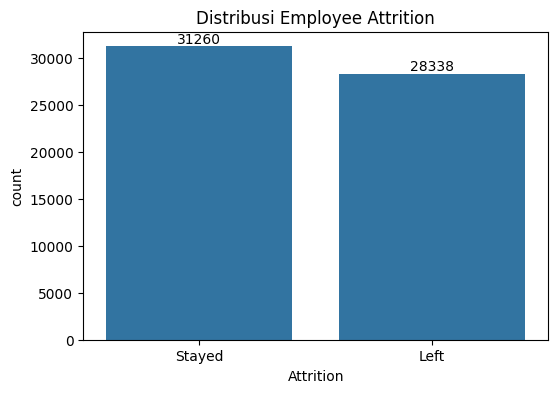

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x='Attrition'
)

plt.title('Distribusi Employee Attrition')
for container in plt.gca().containers:
    plt.bar_label(container)
plt.show()

## Numerical Feature Analysis

In [14]:
numerical_cols = [
    'Age',
    'Years at Company',
    'Monthly Income',
    'Number of Promotions',
    'Distance from Home',
    'Company Tenure',
    'Number of Dependents'
]

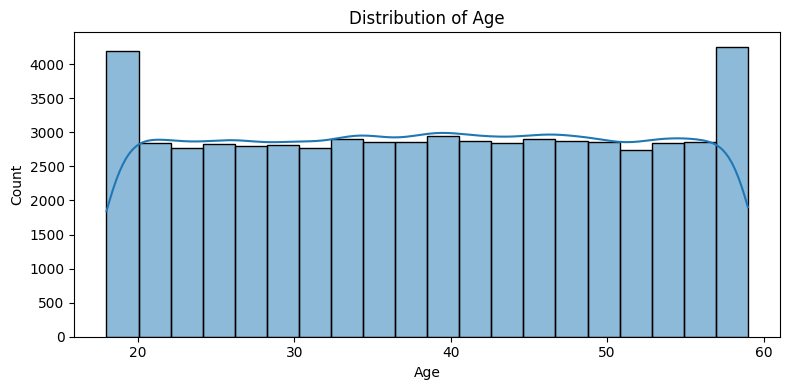

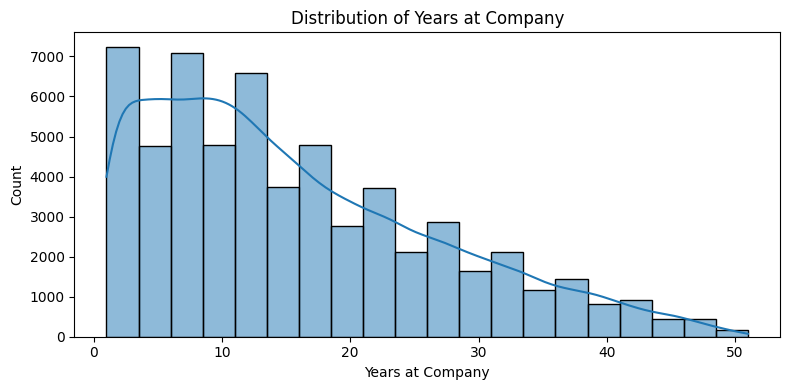

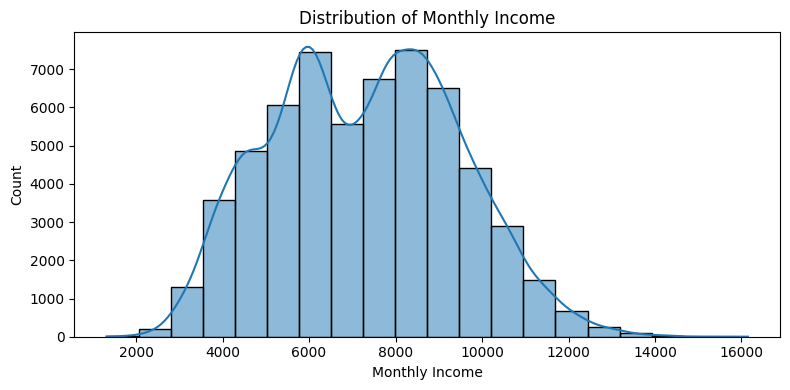

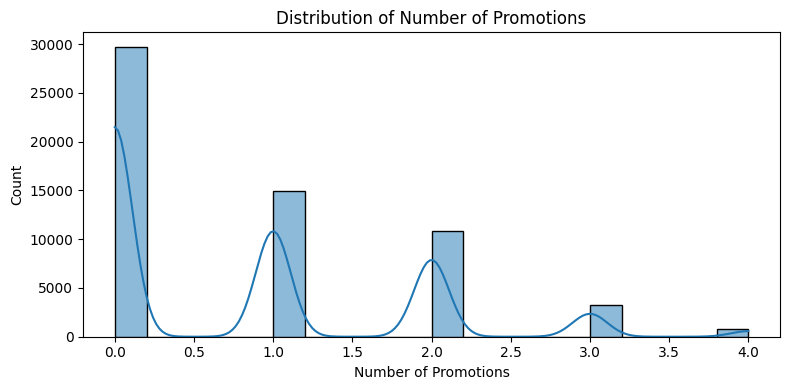

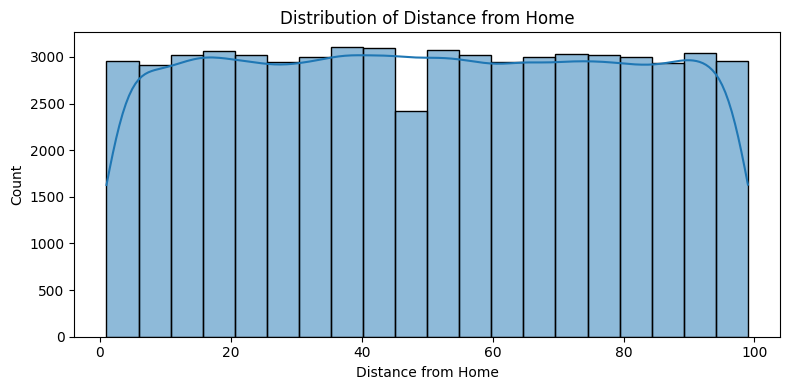

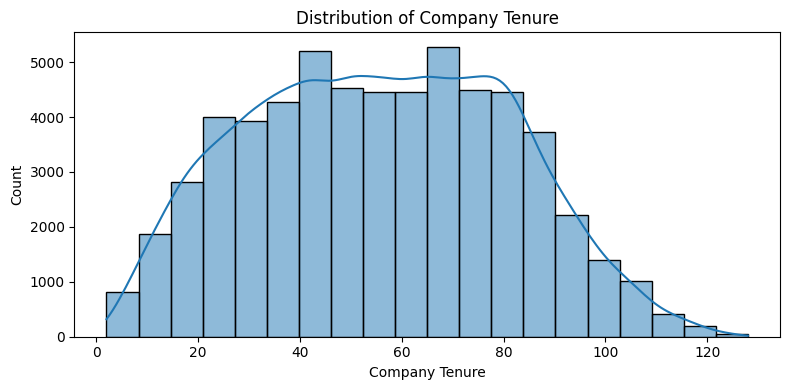

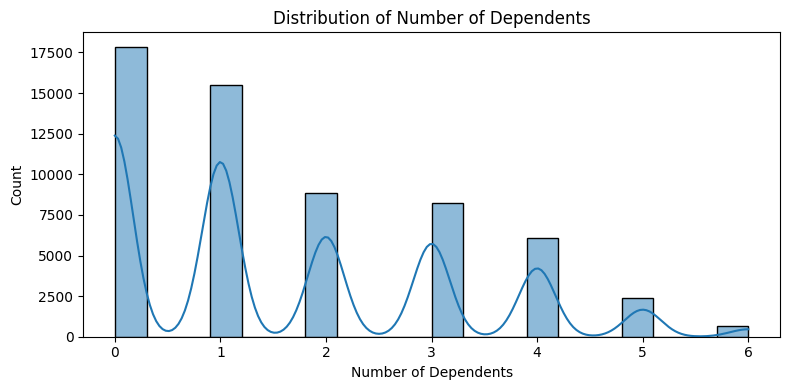

In [15]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=train_df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

## Categorical Feature Analysis

In [16]:
categorical_cols = [
    'Gender',
    'Job Role',
    'Work-Life Balance',
    'Job Satisfaction',
    'Performance Rating',
    'Overtime',
    'Education Level',
    'Marital Status',
    'Job Level',
    'Company Size',
    'Remote Work',
    'Leadership Opportunities',
    'Innovation Opportunities',
    'Company Reputation',
    'Employee Recognition'
]

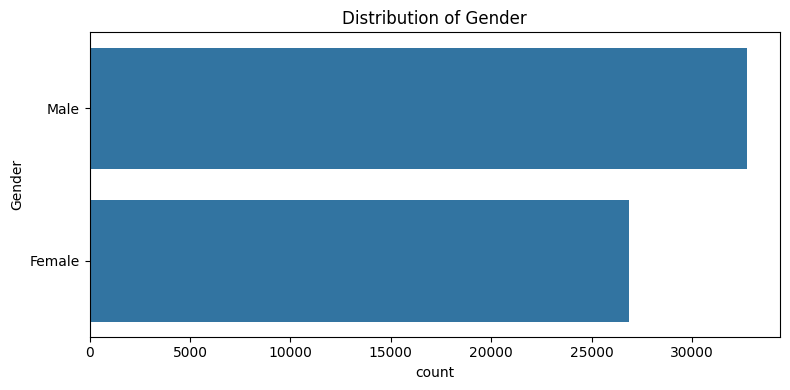

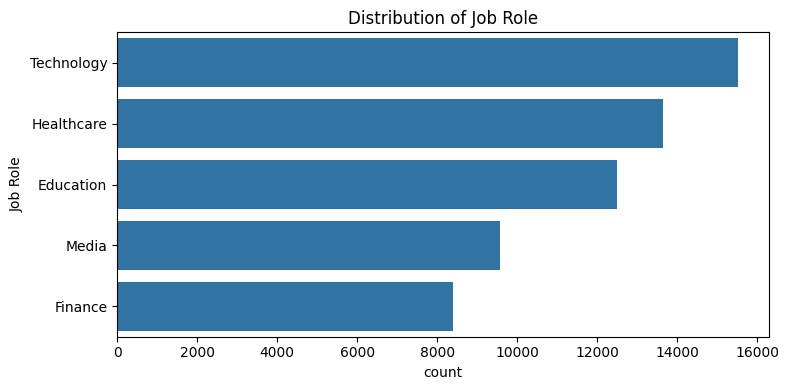

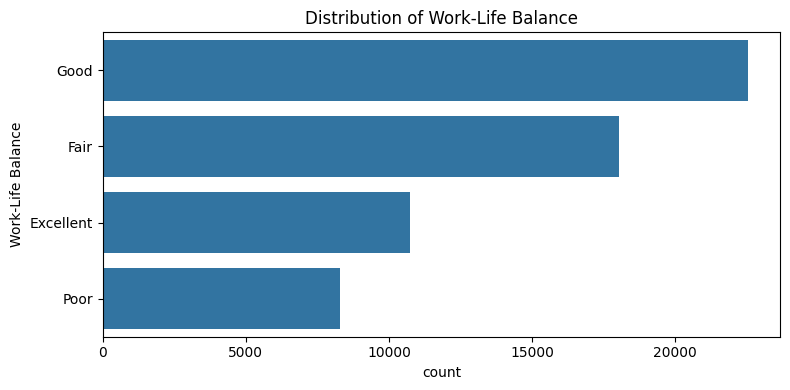

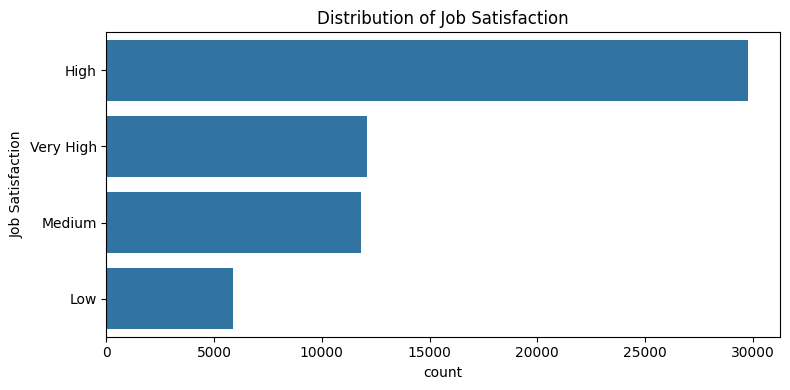

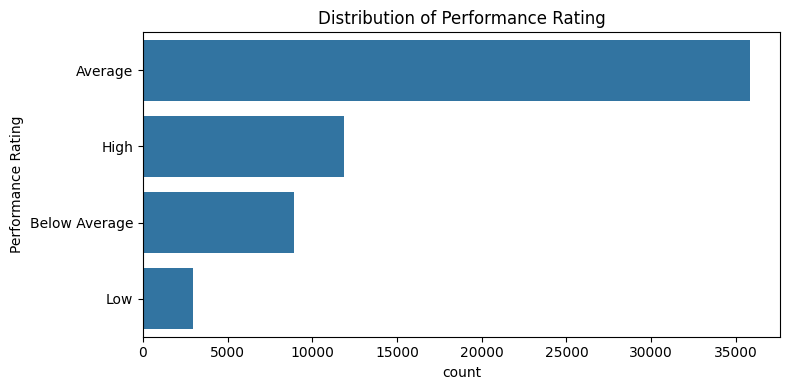

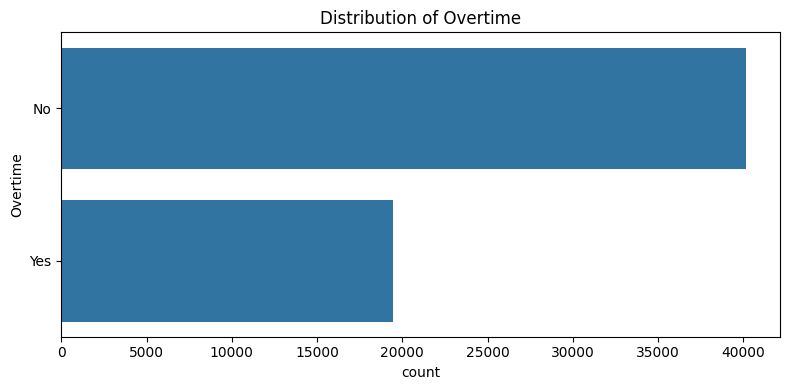

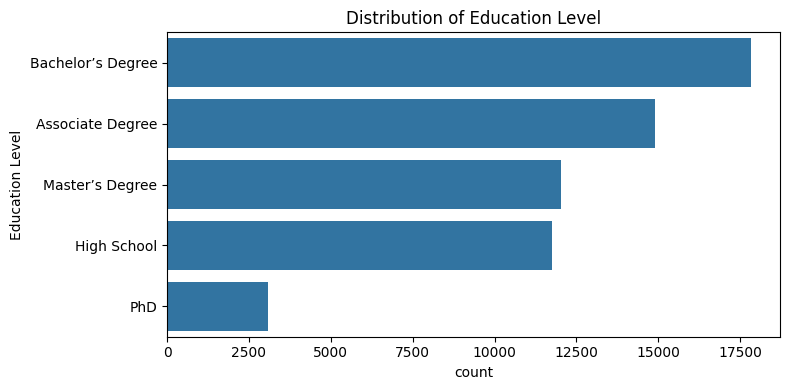

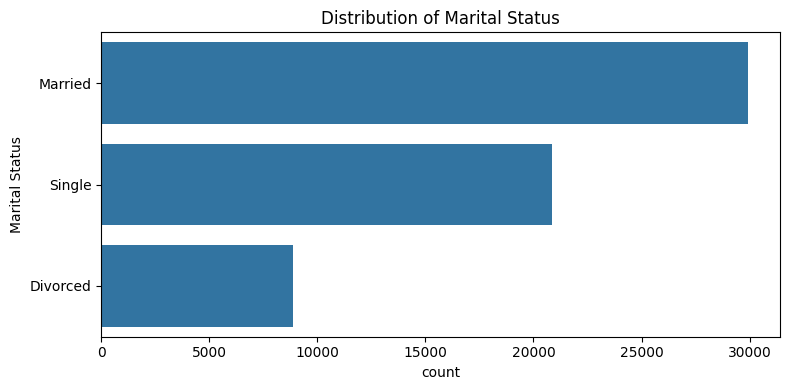

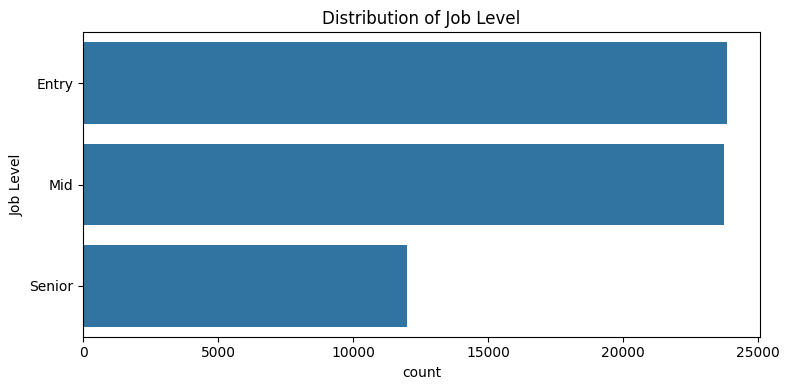

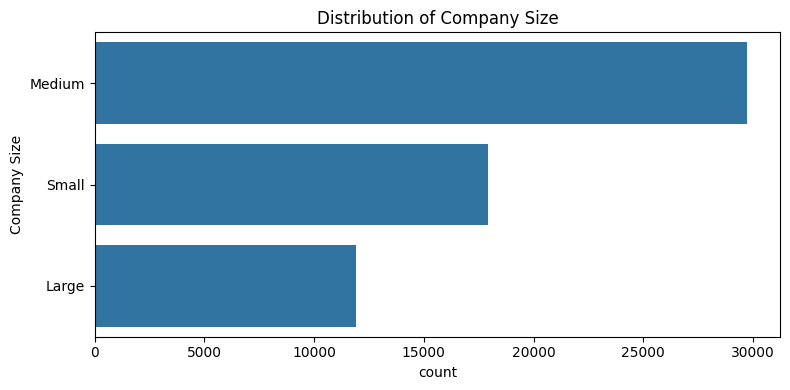

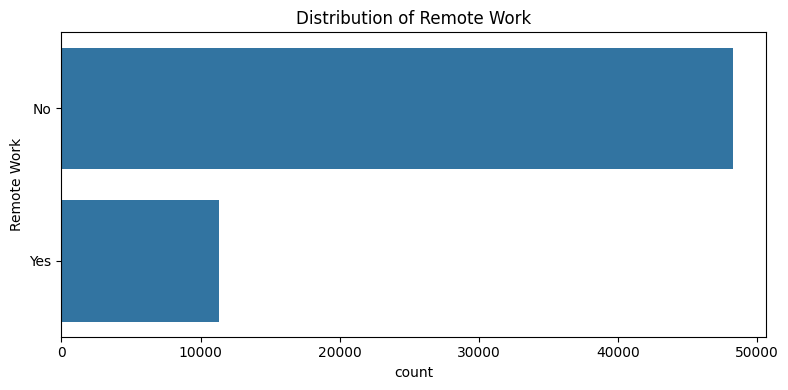

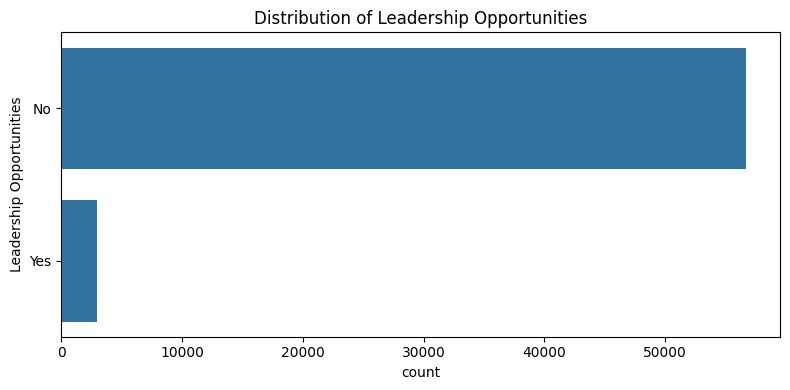

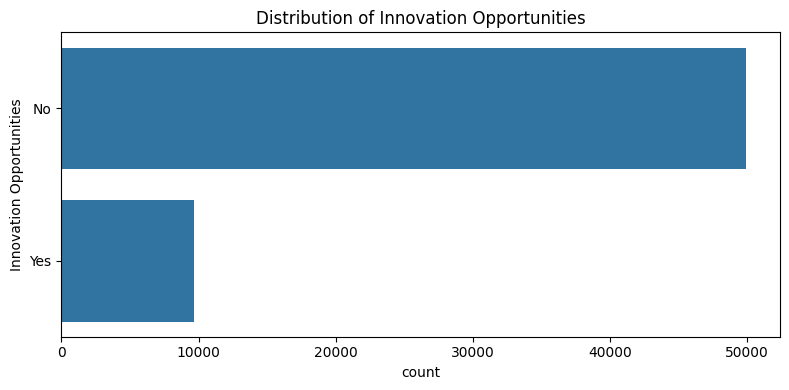

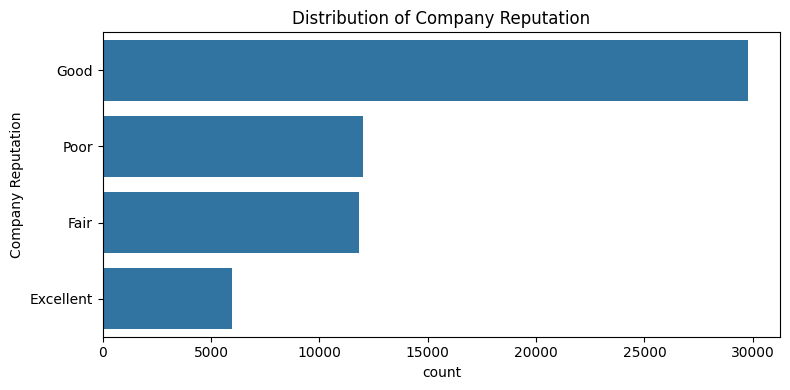

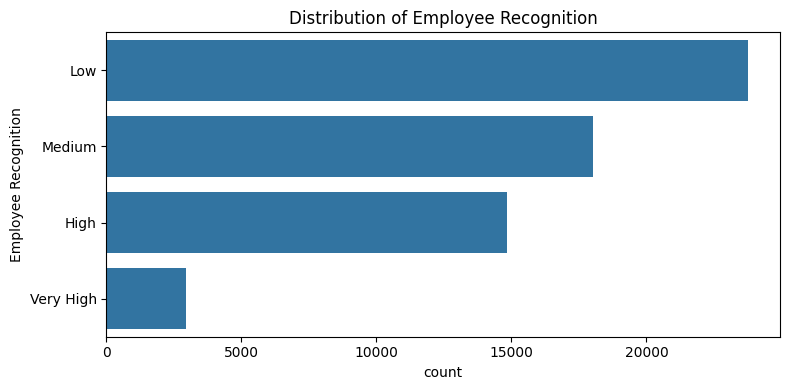

In [17]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=train_df,
        y=col,
        order=train_df[col].value_counts().index
    )

    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

## Feature-Target Relationships

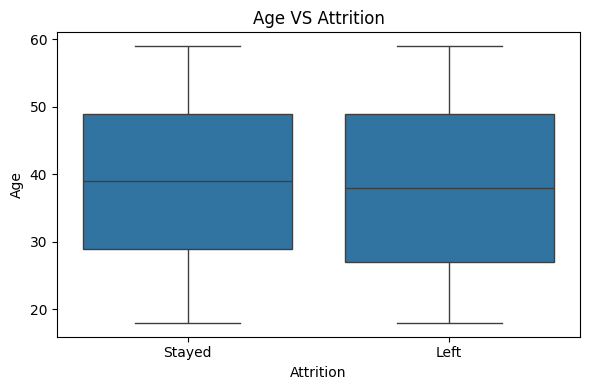

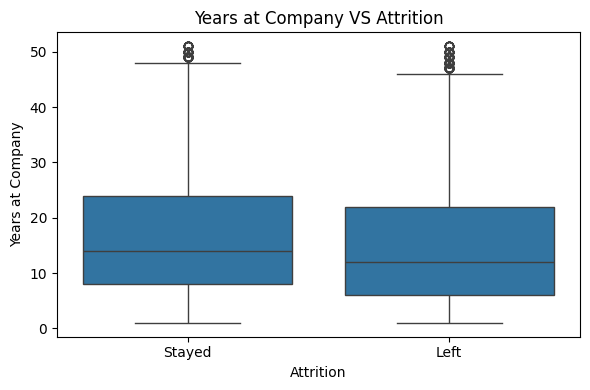

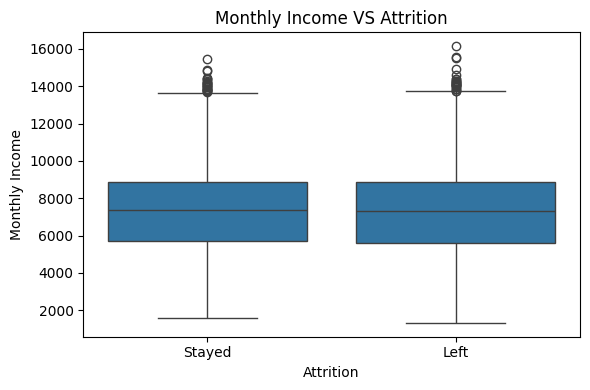

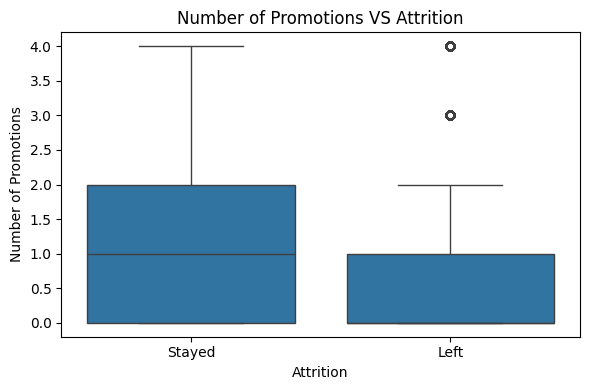

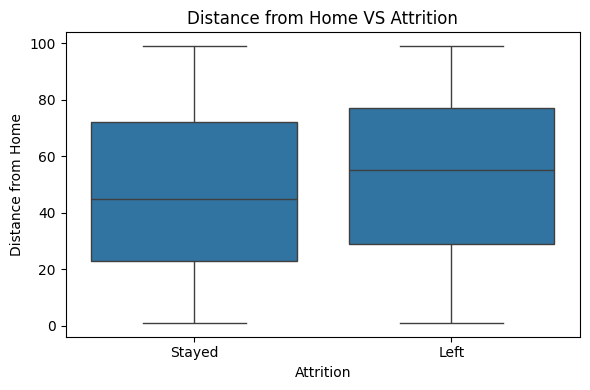

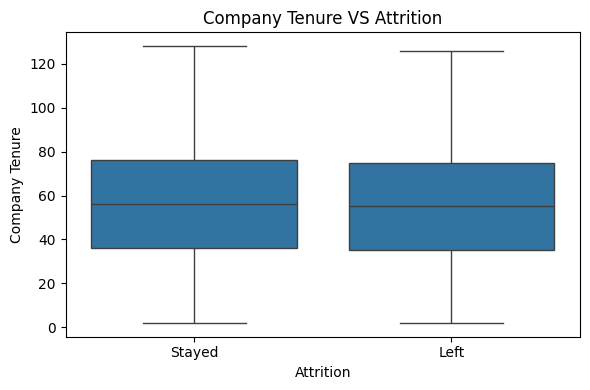

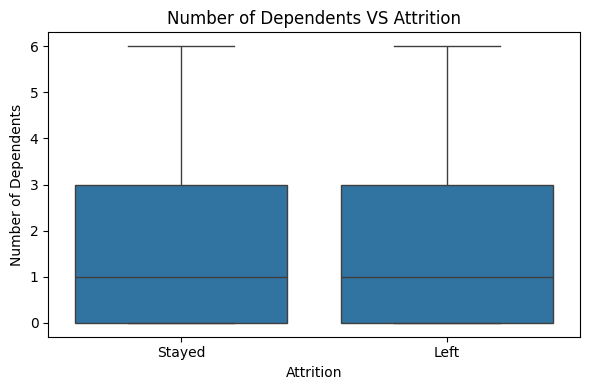

In [18]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=train_df,
        x='Attrition',
        y=col
    )

    plt.title(f'{col} VS Attrition')
    plt.tight_layout()
    plt.show()

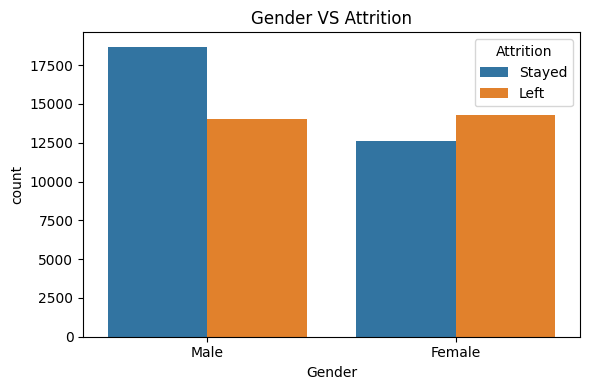

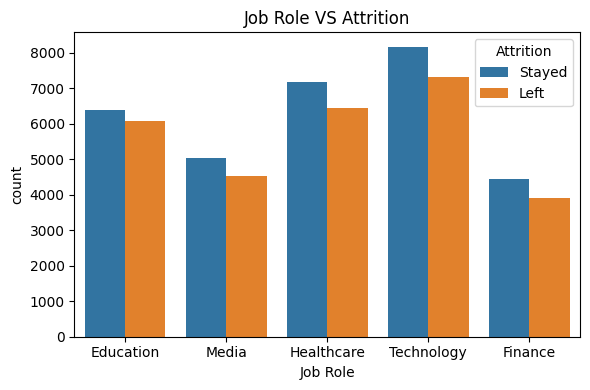

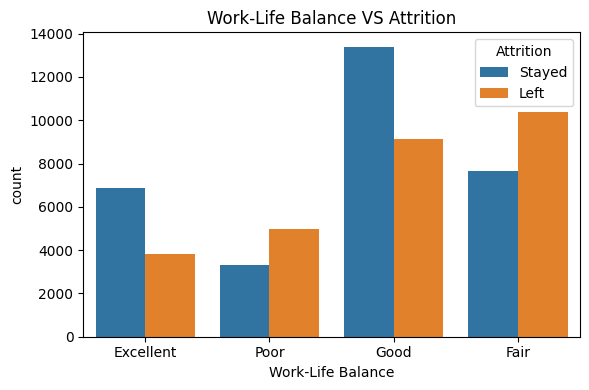

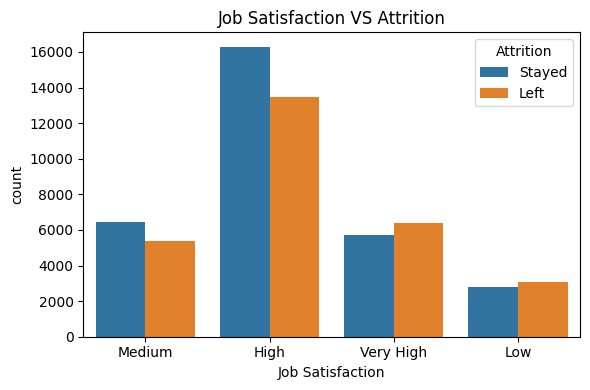

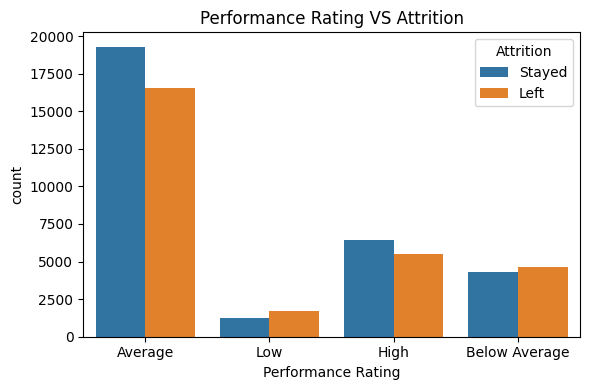

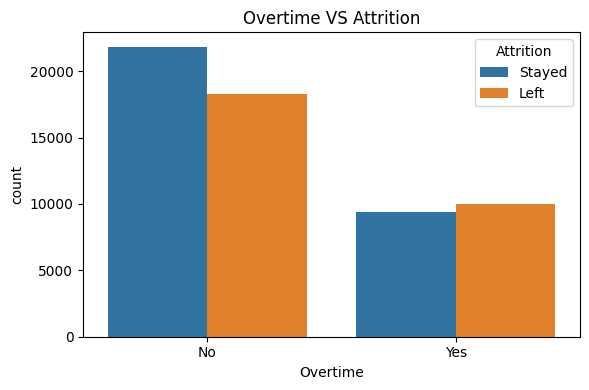

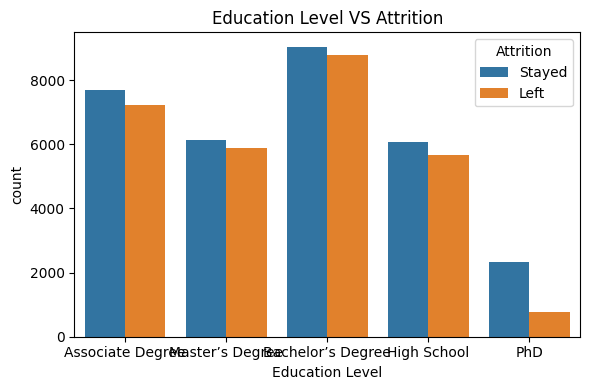

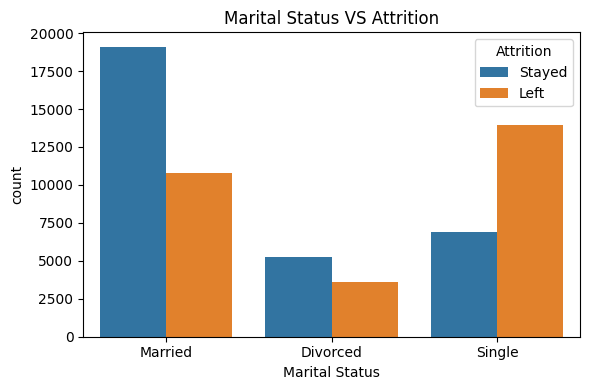

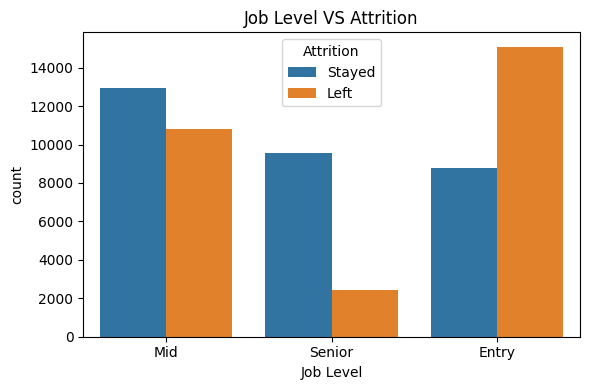

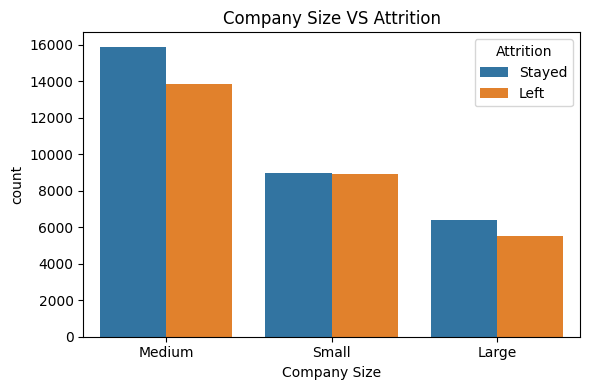

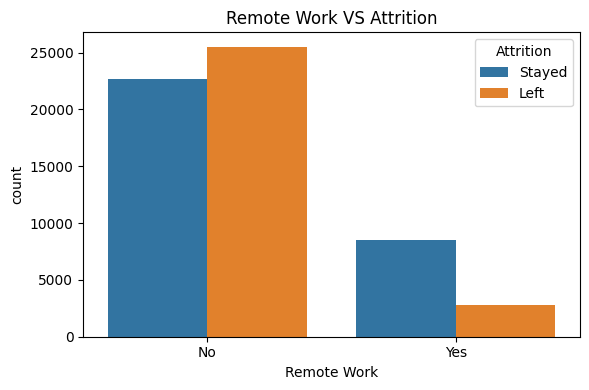

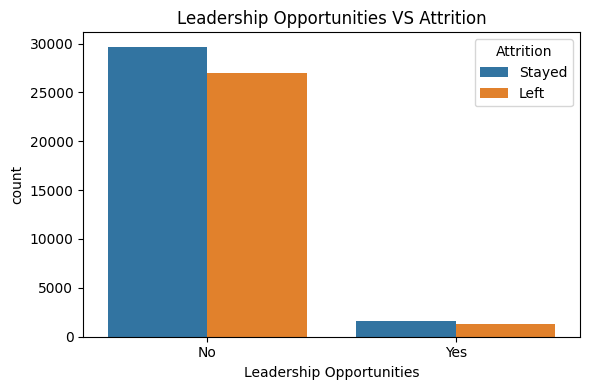

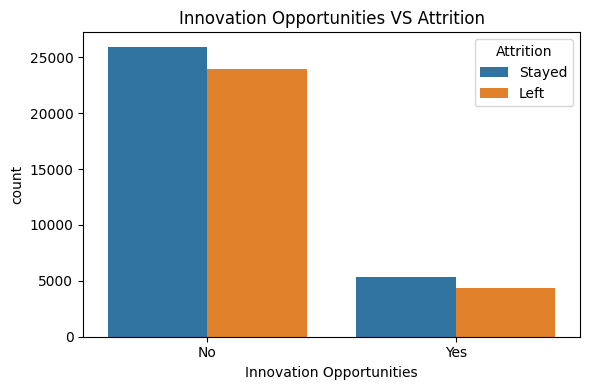

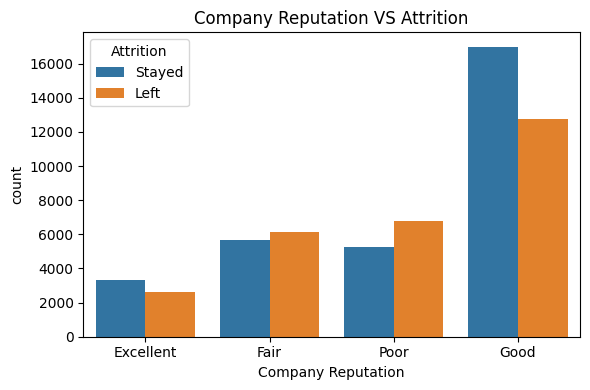

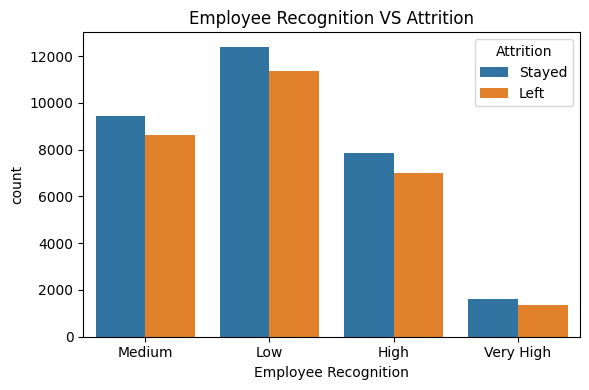

In [19]:
for col in categorical_cols:
    plt.figure(figsize=(6, 4))

    sns.countplot(
        data=train_df,
        x=col,
        hue='Attrition'
    )

    plt.title(f'{col} VS Attrition')
    plt.tight_layout()
    plt.show()

## Heatmap (Correlation Matrix)

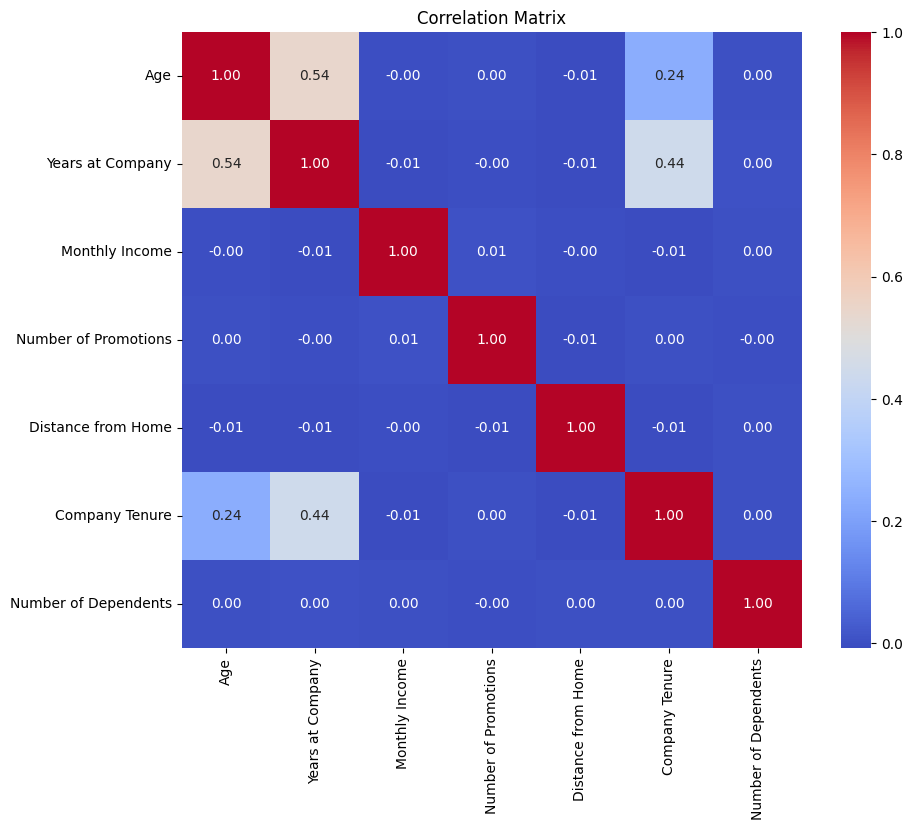

In [20]:
plt.figure(figsize=(10,8))

corr = train_df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

# Data Preprocessing

## Drop "Employee ID" Feature

In [21]:
train_df = train_df.drop(columns=['Employee ID'])
test_df = test_df.drop(columns=['Employee ID'])

## Encode Target Variable

In [22]:
mapping = {
    'Stayed': 0,
    'Left': 1
}

In [23]:
train_df['Attrition'] = train_df['Attrition'].map(mapping)
test_df['Attrition'] = test_df['Attrition'].map(mapping)

## Feature and Target Separation

In [24]:
X = train_df.drop(columns=['Attrition'])
y = train_df['Attrition']

In [25]:
X_test = test_df.drop(columns=['Attrition'])
y_test = test_df['Attrition']

## Data Splitting

In [26]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Setup Pipeline Preprocessing

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), categorical_cols)
    ],
    remainder='drop'
)

In [28]:
X_train_scaled_arr = preprocessor.fit_transform(X_train, y_train)
X_val_scaled_arr   = preprocessor.transform(X_val)
X_test_scaled_arr  = preprocessor.transform(X_test)

In [29]:
all_feature_names = numerical_cols + preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()

In [30]:
X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=all_feature_names, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled_arr,   columns=all_feature_names, index=X_val.index)
X_test_scaled  = pd.DataFrame(X_test_scaled_arr,  columns=all_feature_names, index=X_test.index)

## Feature Selection (ANOVA)

In [31]:
k = 25

In [32]:
selector_anova = SelectKBest(score_func=f_classif, k=k)
selector_anova.fit(X_train_scaled, y_train)

selected_mask     = selector_anova.get_support()
selected_features = X_train_scaled.columns[selected_mask].tolist()

In [33]:
feature_scores = pd.DataFrame({
    'Feature': selected_features,
    'ANOVA Score': selector_anova.scores_[selected_mask]
}).sort_values(by='ANOVA Score', ascending=False)

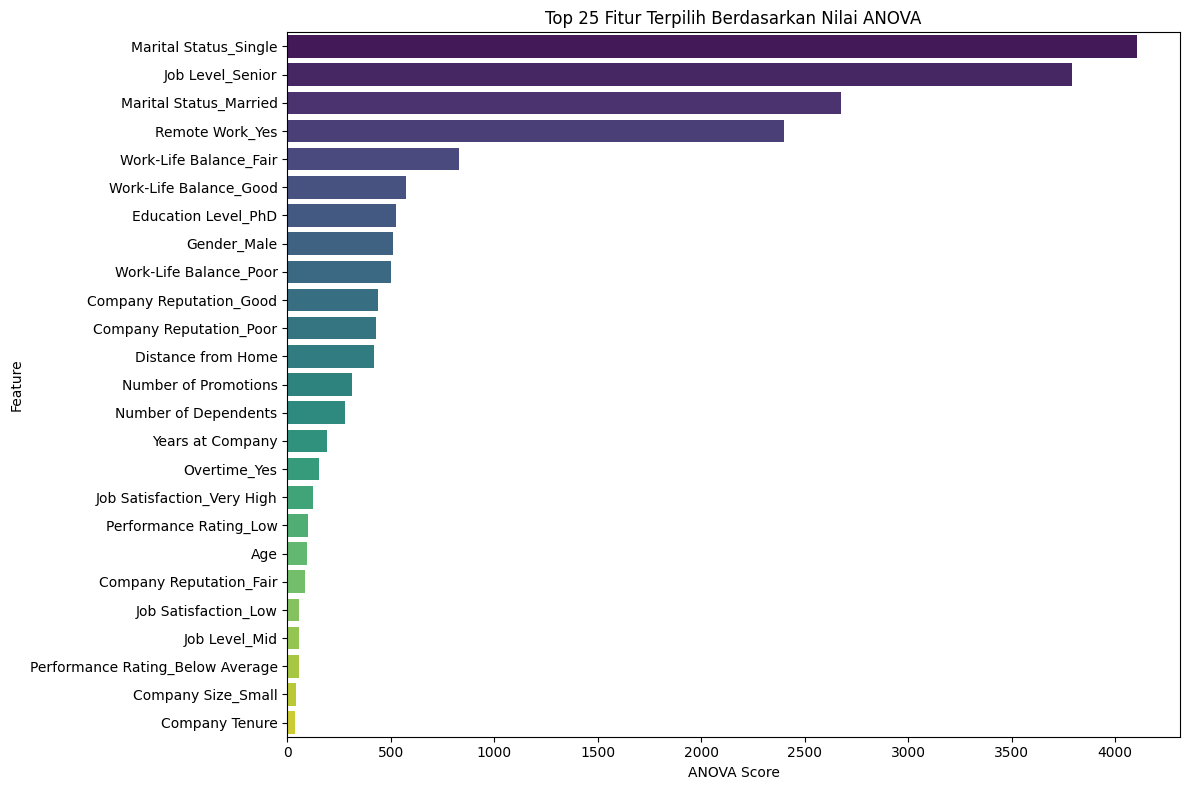

In [34]:
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_scores, x='ANOVA Score', y='Feature', palette='viridis')
plt.title(f'Top {k} Fitur Terpilih Berdasarkan Nilai ANOVA')
plt.xlabel('ANOVA Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Baseline: *Base Models + Raw Data*

## Baseline Preparation

In [35]:
preprocessor_bs = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), categorical_cols)
    ],
    remainder='passthrough'
)

In [36]:
X_train_bs, X_val_bs = X_train, X_val
y_train_bs, y_val_bs = y_train, y_val

## KNN Baseline

In [37]:
knn_bs = Pipeline([
    ('prep', preprocessor_bs),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

In [38]:
knn_bs.fit(X_train_bs, y_train_bs)
y_pred_knn_bs = knn_bs.predict(X_val_bs)

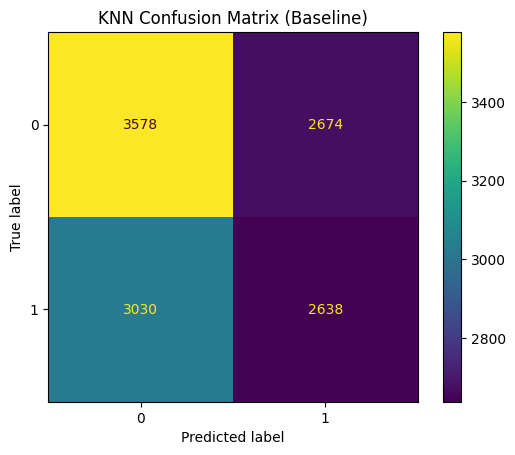

In [39]:
cm_knn_bs = confusion_matrix(y_val_bs, y_pred_knn_bs)
ConfusionMatrixDisplay(cm_knn_bs).plot()
plt.title('KNN Confusion Matrix (Baseline)')
plt.show()

In [40]:
accuracy_knn_bs = accuracy_score(y_val_bs, y_pred_knn_bs)
precision_knn_bs = precision_score(y_val_bs, y_pred_knn_bs)
recall_knn_bs = recall_score(y_val_bs, y_pred_knn_bs)
f1_knn_bs = f1_score(y_val_bs, y_pred_knn_bs)

print(f"KNN Accuracy (Baseline): {accuracy_knn_bs:.4f}")
print(f"KNN Precision (Baseline): {precision_knn_bs:.4f}")
print(f"KNN Recall (Baseline): {recall_knn_bs:.4f}")
print(f"KNN F1-score (Baseline): {f1_knn_bs:.4f}")

KNN Accuracy (Baseline): 0.5215
KNN Precision (Baseline): 0.4966
KNN Recall (Baseline): 0.4654
KNN F1-score (Baseline): 0.4805


## Naive Bayes Baseline

In [41]:
nb_bs = Pipeline([
    ('prep', clone(preprocessor_bs)),
    ('nb', GaussianNB())
])

In [42]:
nb_bs.fit(X_train_bs, y_train_bs)
y_pred_nb_bs = nb_bs.predict(X_val_bs)

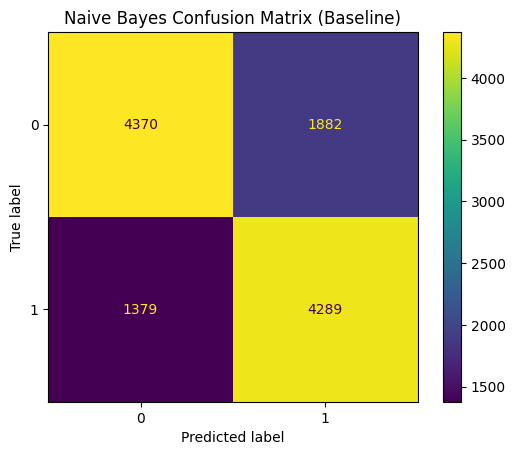

In [43]:
cm_nb_bs = confusion_matrix(y_val_bs, y_pred_nb_bs)
ConfusionMatrixDisplay(cm_nb_bs).plot()
plt.title('Naive Bayes Confusion Matrix (Baseline)')
plt.show()

In [44]:
accuracy_nb_bs = accuracy_score(y_val_bs, y_pred_nb_bs)
precision_nb_bs = precision_score(y_val_bs, y_pred_nb_bs)
recall_nb_bs = recall_score(y_val_bs, y_pred_nb_bs)
f1_nb_bs = f1_score(y_val_bs, y_pred_nb_bs)

print(f"Naive Bayes Accuracy (Baseline): {accuracy_nb_bs:.4f}")
print(f"Naive Bayes Precision (Baseline): {precision_nb_bs:.4f}")
print(f"Naive Bayes Recall (Baseline): {recall_nb_bs:.4f}")
print(f"Naive Bayes F1-score (Baseline): {f1_nb_bs:.4f}")

Naive Bayes Accuracy (Baseline): 0.7264
Naive Bayes Precision (Baseline): 0.6950
Naive Bayes Recall (Baseline): 0.7567
Naive Bayes F1-score (Baseline): 0.7246


## Random Forest Baseline

In [45]:
rf_bs = Pipeline([
    ('prep', clone(preprocessor_bs)),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [46]:
rf_bs.fit(X_train_bs, y_train_bs)
y_pred_rf_bs = rf_bs.predict(X_val_bs)

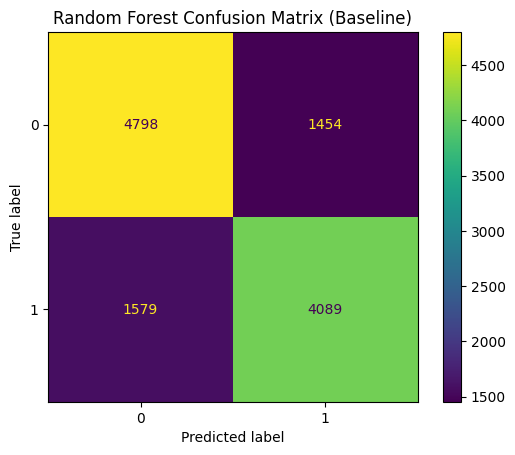

In [47]:
cm_rf_bs = confusion_matrix(y_val_bs, y_pred_rf_bs)
ConfusionMatrixDisplay(cm_rf_bs).plot()
plt.title('Random Forest Confusion Matrix (Baseline)')
plt.show()

In [48]:
accuracy_rf_bs = accuracy_score(y_val_bs, y_pred_rf_bs)
precision_rf_bs = precision_score(y_val_bs, y_pred_rf_bs)
recall_rf_bs = recall_score(y_val_bs, y_pred_rf_bs)
f1_rf_bs = f1_score(y_val_bs, y_pred_rf_bs)

print(f"Random Forest Accuracy (Baseline): {accuracy_rf_bs:.4f}")
print(f"Random Forest Precision (Baseline): {precision_rf_bs:.4f}")
print(f"Random Forest Recall (Baseline): {recall_rf_bs:.4f}")
print(f"Random Forest F1-score (Baseline): {f1_rf_bs:.4f}")

Random Forest Accuracy (Baseline): 0.7456
Random Forest Precision (Baseline): 0.7377
Random Forest Recall (Baseline): 0.7214
Random Forest F1-score (Baseline): 0.7295


## Baseline Comparison

In [49]:
performance_metrics_bs = [
    ['KNN', accuracy_knn_bs, precision_knn_bs, recall_knn_bs, f1_knn_bs],
    ['Naive Bayes', accuracy_nb_bs, precision_nb_bs, recall_nb_bs, f1_nb_bs],
    ['Random Forest', accuracy_rf_bs, precision_rf_bs, recall_rf_bs, f1_rf_bs]
]

metrics_bs_df = pd.DataFrame(
    performance_metrics_bs,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

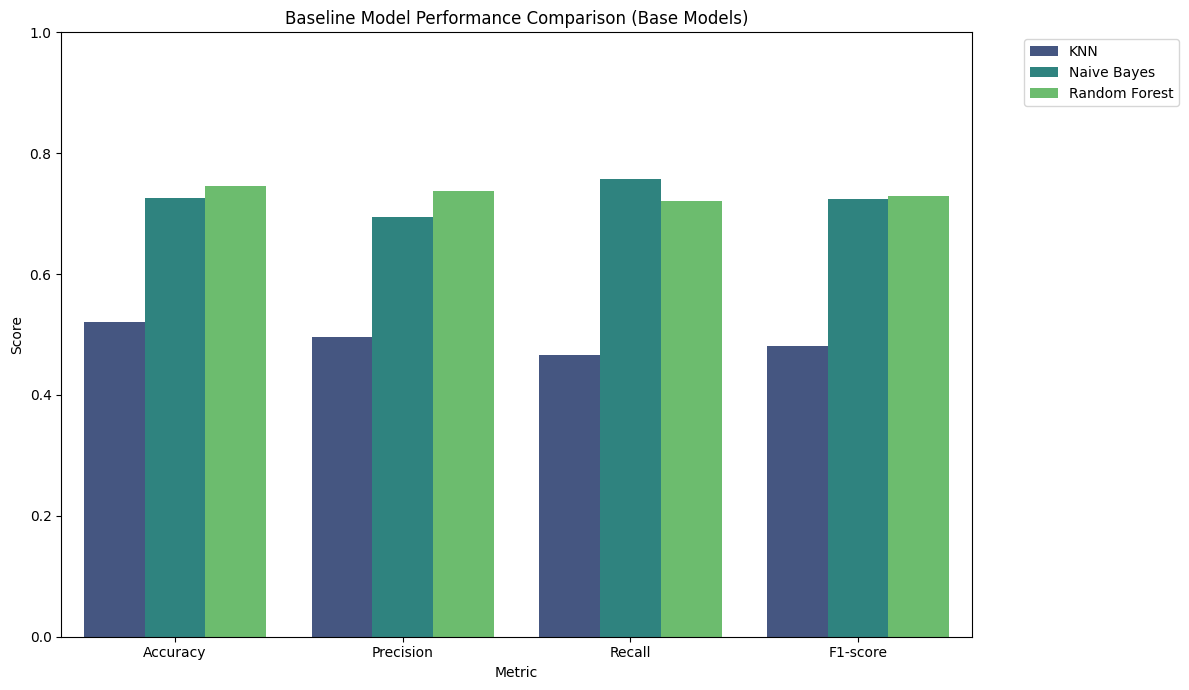

In [50]:
metrics_bs_df_melted = metrics_bs_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=metrics_bs_df_melted,
    palette='viridis'
)
plt.title('Baseline Model Performance Comparison (Base Models)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scenario 1: *Base Models + Normalization*

## Scenario 1 Preparation

In [51]:
X_train_s1, X_val_s1 = X_train_scaled, X_val_scaled
y_train_s1, y_val_s1 = y_train, y_val

## KNN

In [52]:
knn_s1 = KNeighborsClassifier(n_neighbors=5)

In [53]:
knn_s1.fit(X_train_s1, y_train_s1)
y_pred_knn_s1 = knn_s1.predict(X_val_s1)

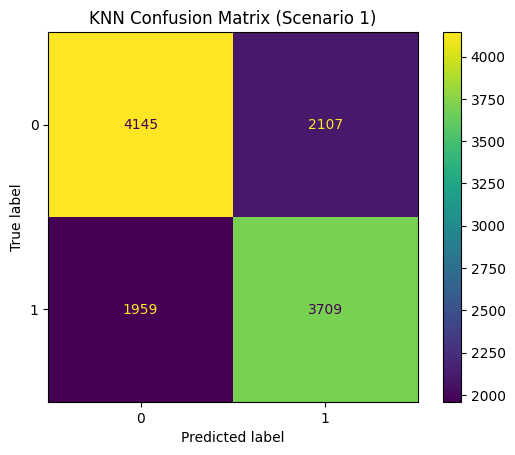

In [54]:
cm_knn_s1 = confusion_matrix(y_val_s1, y_pred_knn_s1)
ConfusionMatrixDisplay(cm_knn_s1).plot()
plt.title('KNN Confusion Matrix (Scenario 1)')
plt.show()

In [55]:
accuracy_knn_s1 = accuracy_score(y_val_s1, y_pred_knn_s1)
precision_knn_s1 = precision_score(y_val_s1, y_pred_knn_s1)
recall_knn_s1 = recall_score(y_val_s1, y_pred_knn_s1)
f1_knn_s1 = f1_score(y_val_s1, y_pred_knn_s1)

print(f"KNN Accuracy (Scenario 1): {accuracy_knn_s1:.4f}")
print(f"KNN Precision (Scenario 1): {precision_knn_s1:.4f}")
print(f"KNN Recall (Scenario 1): {recall_knn_s1:.4f}")
print(f"KNN F1-score (Scenario 1): {f1_knn_s1:.4f}")

KNN Accuracy (Scenario 1): 0.6589
KNN Precision (Scenario 1): 0.6377
KNN Recall (Scenario 1): 0.6544
KNN F1-score (Scenario 1): 0.6459


## Naive Bayes

In [56]:
nb_s1 = GaussianNB()

In [57]:
nb_s1.fit(X_train_s1, y_train_s1)
y_pred_nb_s1 = nb_s1.predict(X_val_s1)

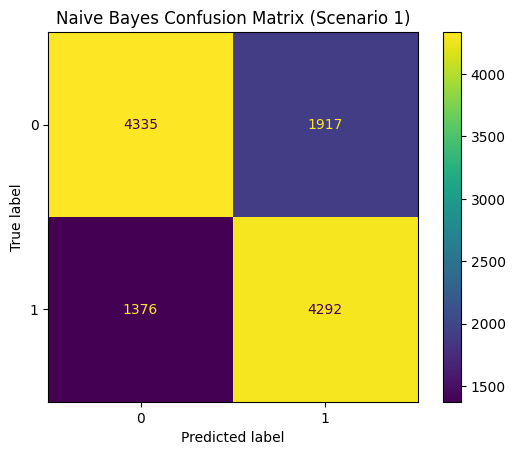

In [58]:
cm_nb_s1 = confusion_matrix(y_val_s1, y_pred_nb_s1)
ConfusionMatrixDisplay(cm_nb_s1).plot()
plt.title('Naive Bayes Confusion Matrix (Scenario 1)')
plt.show()

In [59]:
accuracy_nb_s1 = accuracy_score(y_val_s1, y_pred_nb_s1)
precision_nb_s1 = precision_score(y_val_s1, y_pred_nb_s1)
recall_nb_s1 = recall_score(y_val_s1, y_pred_nb_s1)
f1_nb_s1 = f1_score(y_val_s1, y_pred_nb_s1)

print(f"Naive Bayes Accuracy (Scenario 1): {accuracy_nb_s1:.4f}")
print(f"Naive Bayes Precision (Scenario 1): {precision_nb_s1:.4f}")
print(f"Naive Bayes Recall (Scenario 1): {recall_nb_s1:.4f}")
print(f"Naive Bayes F1-score (Scenario 1): {f1_nb_s1:.4f}")

Naive Bayes Accuracy (Scenario 1): 0.7237
Naive Bayes Precision (Scenario 1): 0.6913
Naive Bayes Recall (Scenario 1): 0.7572
Naive Bayes F1-score (Scenario 1): 0.7227


## Random Forest

In [60]:
rf_s1 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [61]:
rf_s1.fit(X_train_s1, y_train_s1)
y_pred_rf_s1 = rf_s1.predict(X_val_s1)

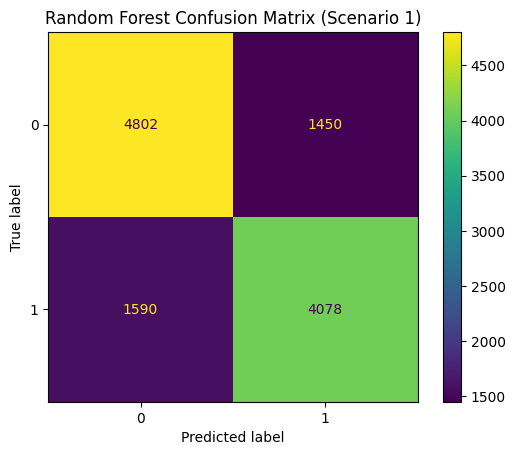

In [62]:
cm_rf_s1 = confusion_matrix(y_val_s1, y_pred_rf_s1)
ConfusionMatrixDisplay(cm_rf_s1).plot()
plt.title('Random Forest Confusion Matrix (Scenario 1)')
plt.show()

In [63]:
accuracy_rf_s1 = accuracy_score(y_val_s1, y_pred_rf_s1)
precision_rf_s1 = precision_score(y_val_s1, y_pred_rf_s1)
recall_rf_s1 = recall_score(y_val_s1, y_pred_rf_s1)
f1_rf_s1 = f1_score(y_val_s1, y_pred_rf_s1)

print(f"Random Forest Accuracy (Scenario 1): {accuracy_rf_s1:.4f}")
print(f"Random Forest Precision (Scenario 1): {precision_rf_s1:.4f}")
print(f"Random Forest Recall (Scenario 1): {recall_rf_s1:.4f}")
print(f"Random Forest F1-score (Scenario 1): {f1_rf_s1:.4f}")

Random Forest Accuracy (Scenario 1): 0.7450
Random Forest Precision (Scenario 1): 0.7377
Random Forest Recall (Scenario 1): 0.7195
Random Forest F1-score (Scenario 1): 0.7285


## Scenario 1 Comparison

In [64]:
performance_metrics_s1 = [
    ['KNN', accuracy_knn_s1, precision_knn_s1, recall_knn_s1, f1_knn_s1],
    ['Naive Bayes', accuracy_nb_s1, precision_nb_s1, recall_nb_s1, f1_nb_s1],
    ['Random Forest', accuracy_rf_s1, precision_rf_s1, recall_rf_s1, f1_rf_s1]
]

metrics_s1_df = pd.DataFrame(
    performance_metrics_s1,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

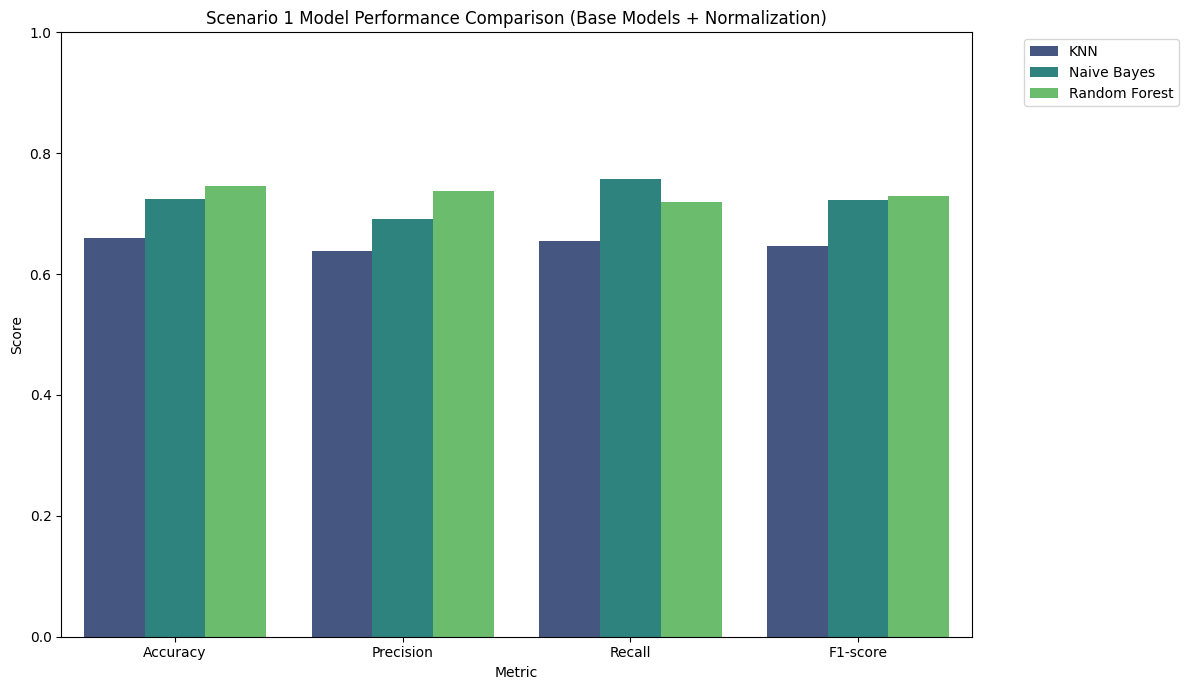

In [65]:
metrics_s1_df_melted = metrics_s1_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=metrics_s1_df_melted,
    palette='viridis'
)
plt.title('Scenario 1 Model Performance Comparison (Base Models + Normalization)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scenario 2: *Tuned Models + Normalization*

## Scenario 2 Preparation

In [66]:
X_train_s2, X_val_s2 = X_train_scaled, X_val_scaled
y_train_s2, y_val_s2 = y_train, y_val

## Scenario 2 Tuning

### KNN Tuning

In [67]:
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

grid_search_knn_s2 = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
grid_search_knn_s2.fit(X_train_s2, y_train_s2)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='f1', verbose=1)

In [68]:
print("Best Parameters (Scenario 2):")
print(grid_search_knn_s2.best_params_)

Best Parameters (Scenario 2):
{'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}


### Naive Bayes Tuning

In [69]:
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_search_nb_s2 = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid_nb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search_nb_s2.fit(X_train_s2, y_train_s2)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


GridSearchCV(cv=5, estimator=GaussianNB(), n_jobs=-1,
             param_grid={'var_smoothing': array([1.00000000e+00, 8.11130831e-01, 6.57933225e-01, 5.33669923e-01,
       4.32876128e-01, 3.51119173e-01, 2.84803587e-01, 2.31012970e-01,
       1.87381742e-01, 1.51991108e-01, 1.23284674e-01, 1.00000000e-01,
       8.11130831e-02, 6.57933225e-02, 5.33669923e-02, 4.32876128e-02,
       3.51119173e-02, 2.8480358...
       1.23284674e-07, 1.00000000e-07, 8.11130831e-08, 6.57933225e-08,
       5.33669923e-08, 4.32876128e-08, 3.51119173e-08, 2.84803587e-08,
       2.31012970e-08, 1.87381742e-08, 1.51991108e-08, 1.23284674e-08,
       1.00000000e-08, 8.11130831e-09, 6.57933225e-09, 5.33669923e-09,
       4.32876128e-09, 3.51119173e-09, 2.84803587e-09, 2.31012970e-09,
       1.87381742e-09, 1.51991108e-09, 1.23284674e-09, 1.00000000e-09])},
             scoring='f1', verbose=1)

In [70]:
print("Best Parameters (Scenario 2):")
print(grid_search_nb_s2.best_params_)

Best Parameters (Scenario 2):
{'var_smoothing': np.float64(0.0533669923120631)}


### Random Forest Tuning

In [71]:
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'ccp_alpha': [0.0, 0.001, 0.005]
}

random_search_rf_s2 = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search_rf_s2.fit(X_train_s2, y_train_s2)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'ccp_alpha': [0.0, 0.001, 0.005],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1', verbose=1)

In [72]:
print("Best Parameters (Scenario 2):")
print(random_search_rf_s2.best_params_)

Best Parameters (Scenario 2):
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'criterion': 'entropy', 'ccp_alpha': 0.0}


##  Tuned KNN

In [73]:
best_knn_s2 = grid_search_knn_s2.best_estimator_

In [74]:
best_knn_s2.fit(X_train_s2, y_train_s2)
y_pred_knn_s2 = best_knn_s2.predict(X_val_s2)

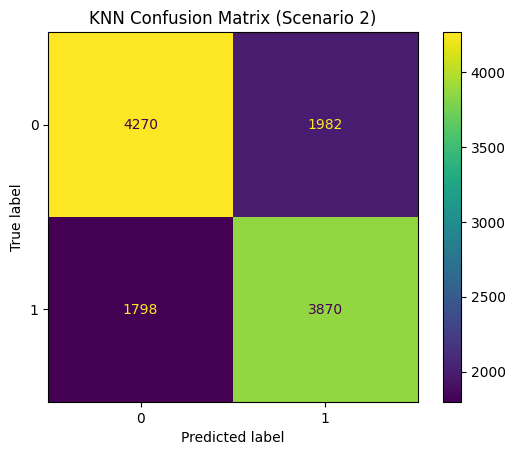

In [75]:
cm_knn_s2 = confusion_matrix(y_val_s2, y_pred_knn_s2)
ConfusionMatrixDisplay(cm_knn_s2).plot()
plt.title('KNN Confusion Matrix (Scenario 2)')
plt.show()

In [76]:
accuracy_knn_s2 = accuracy_score(y_val_s2, y_pred_knn_s2)
precision_knn_s2 = precision_score(y_val_s2, y_pred_knn_s2)
recall_knn_s2 = recall_score(y_val_s2, y_pred_knn_s2)
f1_knn_s2 = f1_score(y_val_s2, y_pred_knn_s2)

print(f"KNN Accuracy (Scenario 2): {accuracy_knn_s2:.4f}")
print(f"KNN Precision (Scenario 2): {precision_knn_s2:.4f}")
print(f"KNN Recall (Scenario 2): {recall_knn_s2:.4f}")
print(f"KNN F1-score (Scenario 2): {f1_knn_s2:.4f}")

KNN Accuracy (Scenario 2): 0.6829
KNN Precision (Scenario 2): 0.6613
KNN Recall (Scenario 2): 0.6828
KNN F1-score (Scenario 2): 0.6719


## Tuned Naive Bayes

In [77]:
best_nb_s2 = grid_search_nb_s2.best_estimator_

In [78]:
best_nb_s2.fit(X_train_s2, y_train_s2)
y_pred_nb_s2 = best_nb_s2.predict(X_val_s2)

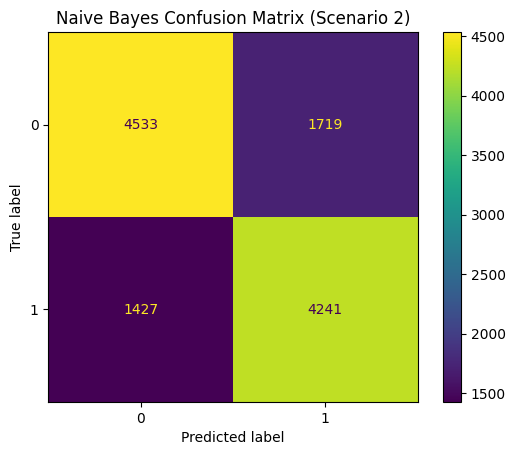

In [79]:
cm_nb_s2 = confusion_matrix(y_val_s2, y_pred_nb_s2)
ConfusionMatrixDisplay(cm_nb_s2).plot()
plt.title('Naive Bayes Confusion Matrix (Scenario 2)')
plt.show()

In [80]:
accuracy_nb_s2 = accuracy_score(y_val_s2, y_pred_nb_s2)
precision_nb_s2 = precision_score(y_val_s2, y_pred_nb_s2)
recall_nb_s2 = recall_score(y_val_s2, y_pred_nb_s2)
f1_nb_s2 = f1_score(y_val_s2, y_pred_nb_s2)

print(f"Naive Bayes Accuracy (Scenario 2): {accuracy_nb_s2:.4f}")
print(f"Naive Bayes Precision (Scenario 2): {precision_nb_s2:.4f}")
print(f"Naive Bayes Recall (Scenario 2): {recall_nb_s2:.4f}")
print(f"Naive Bayes F1-score (Scenario 2): {f1_nb_s2:.4f}")

Naive Bayes Accuracy (Scenario 2): 0.7361
Naive Bayes Precision (Scenario 2): 0.7116
Naive Bayes Recall (Scenario 2): 0.7482
Naive Bayes F1-score (Scenario 2): 0.7294


## Random Forest Feature Selection

In [81]:
best_rf_s2 = random_search_rf_s2.best_estimator_

In [82]:
best_rf_s2.fit(X_train_s2, y_train_s2)
y_pred_rf_s2 = best_rf_s2.predict(X_val_s2)

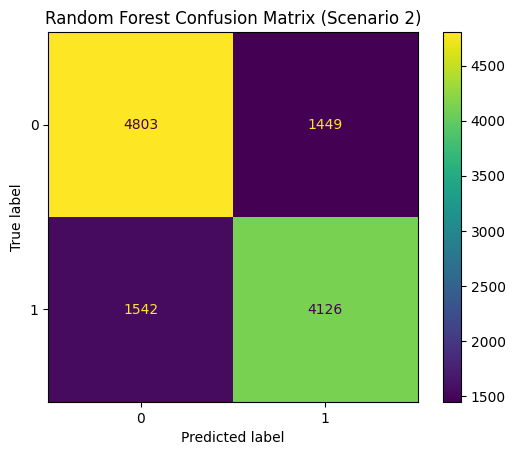

In [83]:
cm_rf_s2 = confusion_matrix(y_val_s2, y_pred_rf_s2)
ConfusionMatrixDisplay(cm_rf_s2).plot()
plt.title('Random Forest Confusion Matrix (Scenario 2)')
plt.show()

In [84]:
accuracy_rf_s2 = accuracy_score(y_val_s2, y_pred_rf_s2)
precision_rf_s2 = precision_score(y_val_s2, y_pred_rf_s2)
recall_rf_s2 = recall_score(y_val_s2, y_pred_rf_s2)
f1_rf_s2 = f1_score(y_val_s2, y_pred_rf_s2)

print(f"Random Forest Accuracy (Scenario 2): {accuracy_rf_s2:.4f}")
print(f"Random Forest Precision (Scenario 2): {precision_rf_s2:.4f}")
print(f"Random Forest Recall (Scenario 2): {recall_rf_s2:.4f}")
print(f"Random Forest F1-score (Scenario 2): {f1_rf_s2:.4f}")

Random Forest Accuracy (Scenario 2): 0.7491
Random Forest Precision (Scenario 2): 0.7401
Random Forest Recall (Scenario 2): 0.7279
Random Forest F1-score (Scenario 2): 0.7340


## Scenario 2 Comparison

In [85]:
performance_metrics_s2 = [
    ['KNN', accuracy_knn_s2, precision_knn_s2, recall_knn_s2, f1_knn_s2],
    ['Naive Bayes', accuracy_nb_s2, precision_nb_s2, recall_nb_s2, f1_nb_s2],
    ['Random Forest', accuracy_rf_s2, precision_rf_s2, recall_rf_s2, f1_rf_s2]
]

metrics_s2_df = pd.DataFrame(
    performance_metrics_s2,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

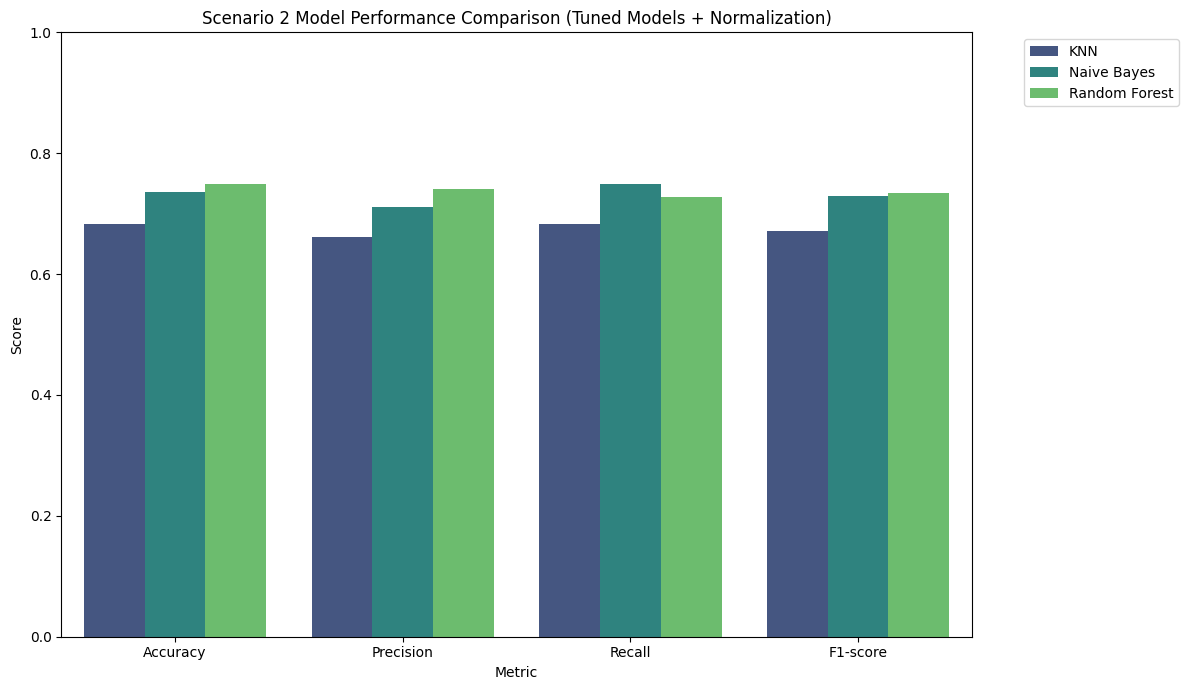

In [86]:
metrics_s2_df_melted = metrics_s2_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=metrics_s2_df_melted,
    palette='viridis'
)
plt.title('Scenario 2 Model Performance Comparison (Tuned Models + Normalization)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scenario 3: *Tuned Models + Normalization + Feature Selection*

## Scenario 3 Preparation

In [87]:
X_train_s3, X_val_s3 = X_train_scaled, X_val_scaled
y_train_s3, y_val_s3 = y_train, y_val

## Scenario 3 Tuning

### KNN Tuning

In [88]:
param_grid_knn_s3 = {
    "classifier__n_neighbors": [3, 5, 7, 9],
    "classifier__weights": ["uniform", "distance"],
    "classifier__p": [1, 2]
}

pipe_knn_s3 = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_classif, k=25)),
    ('classifier', KNeighborsClassifier())
])

grid_search_knn_s3 = GridSearchCV(
    estimator=pipe_knn_s3,
    param_grid=param_grid_knn_s3,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search_knn_s3.fit(X_train_s3, y_train_s3)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('feature_selection', SelectKBest(k=25)),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__n_neighbors': [3, 5, 7, 9],
                         'classifier__p': [1, 2],
                         'classifier__weights': ['uniform', 'distance']},
             scoring='f1', verbose=1)

In [89]:
print("Best Parameters (Scenario 3):")
print(grid_search_knn_s3.best_params_)

Best Parameters (Scenario 3):
{'classifier__n_neighbors': 9, 'classifier__p': 1, 'classifier__weights': 'uniform'}


### Naive Bayes Tuning

In [90]:
param_grid_nb_s3 = {
    "classifier__var_smoothing": np.logspace(0, -9, num=100)
}

pipe_nb_s3 = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_classif, k=25)),
    ('classifier', GaussianNB())
])

grid_search_nb_s3 = GridSearchCV(
    estimator=pipe_nb_s3,
    param_grid=param_grid_nb_s3,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search_nb_s3.fit(X_train_s3, y_train_s3)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('feature_selection', SelectKBest(k=25)),
                                       ('classifier', GaussianNB())]),
             n_jobs=-1,
             param_grid={'classifier__var_smoothing': array([1.00000000e+00, 8.11130831e-01, 6.57933225e-01, 5.33669923e-01,
       4.32876128e-01, 3.51119173e-01, 2.84803587e-01, 2.31012970e-01,
       1.87381742e-01, 1.51991108e-01, 1.23284674e-01, 1.00000000e-01...
       1.23284674e-07, 1.00000000e-07, 8.11130831e-08, 6.57933225e-08,
       5.33669923e-08, 4.32876128e-08, 3.51119173e-08, 2.84803587e-08,
       2.31012970e-08, 1.87381742e-08, 1.51991108e-08, 1.23284674e-08,
       1.00000000e-08, 8.11130831e-09, 6.57933225e-09, 5.33669923e-09,
       4.32876128e-09, 3.51119173e-09, 2.84803587e-09, 2.31012970e-09,
       1.87381742e-09, 1.51991108e-09, 1.23284674e-09, 1.00000000e-09])},
             scoring='f1', verbose=1)

In [91]:
print("Best Parameters (Scenario 3):")
print(grid_search_nb_s3.best_params_)

Best Parameters (Scenario 3):
{'classifier__var_smoothing': np.float64(0.0533669923120631)}


### Random Forest Tuning

In [92]:
param_dist_rf_s3 = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [10, 20, 30, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__criterion": ["gini", "entropy"],
    "classifier__ccp_alpha": [0.0, 0.001, 0.005]
}

pipe_rf_s3 = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_classif, k=25)),
    ('classifier', RandomForestClassifier(random_state=42))
])

random_search_rf_s3 = RandomizedSearchCV(
    estimator=pipe_rf_s3,
    param_distributions=param_dist_rf_s3,
    n_iter=30,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search_rf_s3.fit(X_train_s3, y_train_s3)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('feature_selection',
                                              SelectKBest(k=25)),
                                             ('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'classifier__ccp_alpha': [0.0, 0.001,
                                                                  0.005],
                                        'classifier__criterion': ['gini',
                                                                  'entropy'],
                                        'classifier__max_depth': [10, 20, 30,
                                                                  None],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300,
                                                                     500]},
                   random_state=42, scoring='f1', verbose=1)

In [93]:
print("Best Parameters (Scenario 3):")
print(random_search_rf_s3.best_params_)

Best Parameters (Scenario 3):
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': 30, 'classifier__criterion': 'entropy', 'classifier__ccp_alpha': 0.0}


## Tuned KNN + Feature Selection

In [94]:
best_knn_s3 = grid_search_knn_s3.best_estimator_

In [95]:
best_knn_s3.fit(X_train_s3, y_train_s3)
y_pred_knn_s3 = best_knn_s3.predict(X_val_s3)

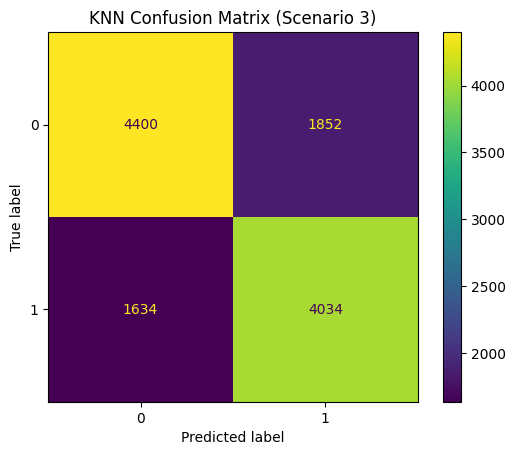

In [96]:
cm_knn_s3 = confusion_matrix(y_val_s3, y_pred_knn_s3)
ConfusionMatrixDisplay(cm_knn_s3).plot()
plt.title('KNN Confusion Matrix (Scenario 3)')
plt.show()

In [97]:
accuracy_knn_s3 = accuracy_score(y_val_s3, y_pred_knn_s3)
precision_knn_s3 = precision_score(y_val_s3, y_pred_knn_s3)
recall_knn_s3 = recall_score(y_val_s3, y_pred_knn_s3)
f1_knn_s3 = f1_score(y_val_s3, y_pred_knn_s3)

print(f"KNN Accuracy (Scenario 3): {accuracy_knn_s3:.4f}")
print(f"KNN Precision (Scenario 3): {precision_knn_s3:.4f}")
print(f"KNN Recall (Scenario 3): {recall_knn_s3:.4f}")
print(f"KNN F1-score (Scenario 3): {f1_knn_s3:.4f}")

KNN Accuracy (Scenario 3): 0.7076
KNN Precision (Scenario 3): 0.6854
KNN Recall (Scenario 3): 0.7117
KNN F1-score (Scenario 3): 0.6983


## Tuned Naive Bayes + Feature Selection

In [98]:
best_nb_s3 = grid_search_nb_s3.best_estimator_

In [99]:
best_nb_s3.fit(X_train_s3, y_train_s3)
y_pred_nb_s3 = best_nb_s3.predict(X_val_s3)

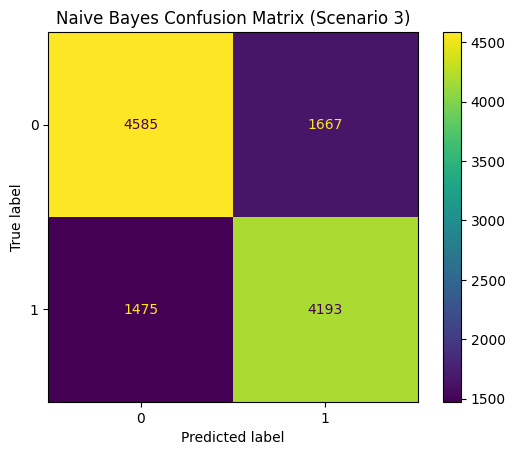

In [100]:
cm_nb_s3 = confusion_matrix(y_val_s3, y_pred_nb_s3)
ConfusionMatrixDisplay(cm_nb_s3).plot()
plt.title('Naive Bayes Confusion Matrix (Scenario 3)')
plt.show()

In [101]:
accuracy_nb_s3 = accuracy_score(y_val_s3, y_pred_nb_s3)
precision_nb_s3 = precision_score(y_val_s3, y_pred_nb_s3)
recall_nb_s3 = recall_score(y_val_s3, y_pred_nb_s3)
f1_nb_s3 = f1_score(y_val_s3, y_pred_nb_s3)

print(f"Naive Bayes Accuracy (Scenario 3): {accuracy_nb_s3:.4f}")
print(f"Naive Bayes Precision (Scenario 3): {precision_nb_s3:.4f}")
print(f"Naive Bayes Recall (Scenario 3): {recall_nb_s3:.4f}")
print(f"Naive Bayes F1-score (Scenario 3): {f1_nb_s3:.4f}")

Naive Bayes Accuracy (Scenario 3): 0.7364
Naive Bayes Precision (Scenario 3): 0.7155
Naive Bayes Recall (Scenario 3): 0.7398
Naive Bayes F1-score (Scenario 3): 0.7274


## Tuned Random Forest + Feature Selection

In [102]:
best_rf_s3 = random_search_rf_s3.best_estimator_

In [103]:
best_rf_s3.fit(X_train_s3, y_train_s3)
y_pred_rf_s3 = best_rf_s3.predict(X_val_s3)

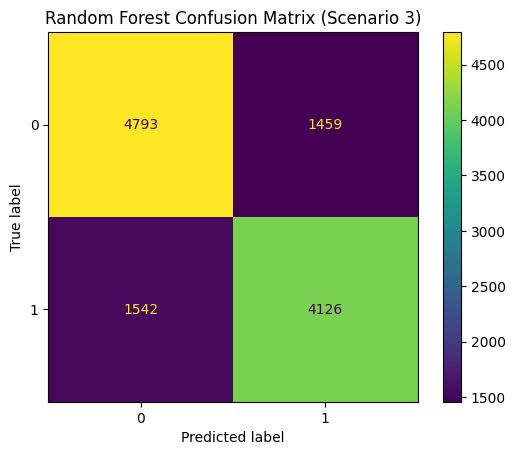

In [104]:
cm_rf_s3 = confusion_matrix(y_val_s3, y_pred_rf_s3)
ConfusionMatrixDisplay(cm_rf_s3).plot()
plt.title('Random Forest Confusion Matrix (Scenario 3)')
plt.show()

In [105]:
accuracy_rf_s3 = accuracy_score(y_val_s3, y_pred_rf_s3)
precision_rf_s3 = precision_score(y_val_s3, y_pred_rf_s3)
recall_rf_s3 = recall_score(y_val_s3, y_pred_rf_s3)
f1_rf_s3 = f1_score(y_val_s3, y_pred_rf_s3)

print(f"Random Forest Accuracy (Scenario 3): {accuracy_rf_s3:.4f}")
print(f"Random Forest Precision (Scenario 3): {precision_rf_s3:.4f}")
print(f"Random Forest Recall (Scenario 3): {recall_rf_s3:.4f}")
print(f"Random Forest F1-score (Scenario 3): {f1_rf_s3:.4f}")

Random Forest Accuracy (Scenario 3): 0.7482
Random Forest Precision (Scenario 3): 0.7388
Random Forest Recall (Scenario 3): 0.7279
Random Forest F1-score (Scenario 3): 0.7333


## Scenario 3 Comparison

In [106]:
performance_metrics_s3 = [
    ['KNN', accuracy_knn_s3, precision_knn_s3, recall_knn_s3, f1_knn_s3],
    ['Naive Bayes', accuracy_nb_s3, precision_nb_s3, recall_nb_s3, f1_nb_s3],
    ['Random Forest', accuracy_rf_s3, precision_rf_s3, recall_rf_s3, f1_rf_s3]
]

metrics_s3_df = pd.DataFrame(
    performance_metrics_s3,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

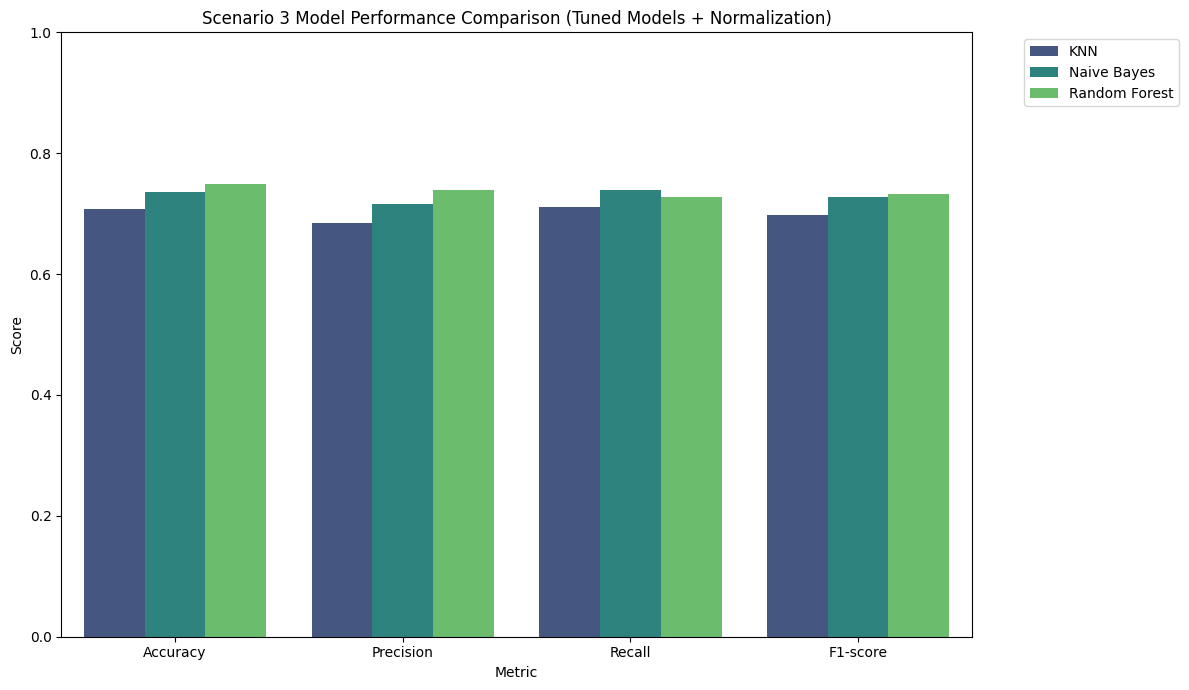

In [107]:
metrics_s3_df_melted = metrics_s3_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=metrics_s3_df_melted,
    palette='viridis'
)
plt.title('Scenario 3 Model Performance Comparison (Tuned Models + Normalization)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Overall Comparison

## Comparison Across Scenarios

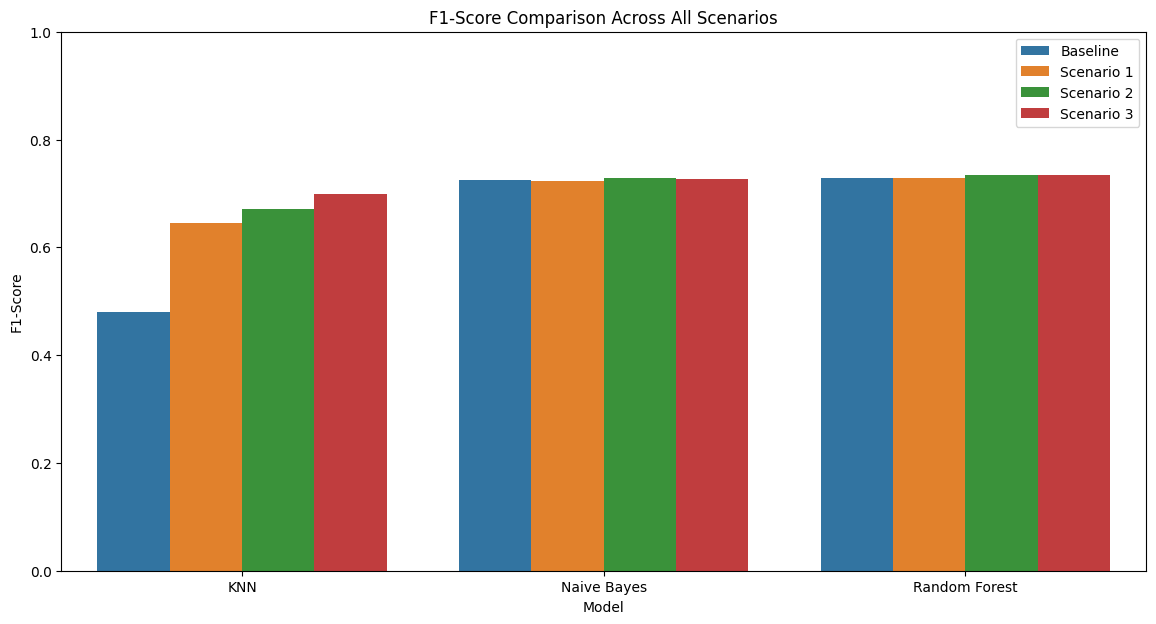

,Model,Accuracy,Precision,Recall,F1-score,Scenario
8,Random Forest,0.749077,0.740090,0.727946,0.733968,Scenario 2
11,Random Forest,0.748238,0.738765,0.727946,0.733316,Scenario 3
2,Random Forest,0.745554,0.737687,0.721418,0.729462,Baseline
7,Naive Bayes,0.736074,0.711577,0.748236,0.729446,Scenario 2
5,Random Forest,0.744966,0.737699,0.719478,0.728474,Scenario 1
10,Naive Bayes,0.736409,0.715529,0.739767,0.727446,Scenario 3
1,Naive Bayes,0.726426,0.695025,0.756704,0.724554,Baseline
4,Naive Bayes,0.723742,0.691255,0.757234,0.722741,Scenario 1
9,KNN,0.707550,0.685355,0.711715,0.698286,Scenario 3
6,KNN,0.682886,0.661312,0.682781,0.671875,Scenario 2


In [108]:
metrics_bs_df['Scenario'] = 'Baseline'
metrics_s1_df['Scenario'] = 'Scenario 1'
metrics_s2_df['Scenario'] = 'Scenario 2'
metrics_s3_df['Scenario'] = 'Scenario 3'
all_scenarios_df = pd.concat([metrics_bs_df, metrics_s1_df, metrics_s2_df, metrics_s3_df], ignore_index=True)

plt.figure(figsize=(14, 7))
sns.barplot(data=all_scenarios_df, x='Model', y='F1-score', hue='Scenario')
plt.title('F1-Score Comparison Across All Scenarios')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.show()

display(all_scenarios_df.sort_values(by='F1-score', ascending=False))

## Best Model Selection

In [109]:
best_model_idx = all_scenarios_df['F1-score'].idxmax()
best_model_row = all_scenarios_df.iloc[best_model_idx]

print(f"Model Terbaik Berdasarkan F1-Score:")
print(f"- Model   : {best_model_row['Model']}")
print(f"- Scenario: {best_model_row['Scenario']}")
print(f"- F1-Score: {best_model_row['F1-score']:.4f}")

Model Terbaik Berdasarkan F1-Score:
- Model   : Random Forest
- Scenario: Scenario 2
- F1-Score: 0.7340


# Testing Best Model on Original Test Dataset

## Load Best Model

In [110]:
best_model = clone(best_rf_s2)
best_model_name = 'Random Forest (Scenario 2)'

In [111]:
best_model.fit(X_train_scaled, y_train)
print(f"Best Model Re-trained: {best_model_name}")

Best Model Re-trained: Random Forest (Scenario 2)


## Original Dataset Overview

In [112]:
display(X_test_scaled.head())

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Company Tenure,Number of Dependents,Gender_Male,Job Role_Finance,Job Role_Healthcare,...,Company Size_Small,Remote Work_Yes,Leadership Opportunities_Yes,Innovation Opportunities_Yes,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
0,-0.211462,-0.243726,0.337605,0.164857,1.157041,-1.329100,-0.415406,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.294241,-0.778160,-1.272372,0.164857,0.175352,-1.132169,1.511594,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.947454,-0.778160,-0.798576,2.171770,-1.262120,0.797747,0.226928,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,1.609691,2.517514,-0.825518,-0.838599,-0.245371,1.585468,1.511594,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.036877,0.736069,-1.253327,-0.838599,-0.105130,-0.423220,2.796261,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Model Prediction

In [113]:
y_pred_test = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

## Model Evaluiation

### Confusion Matrix

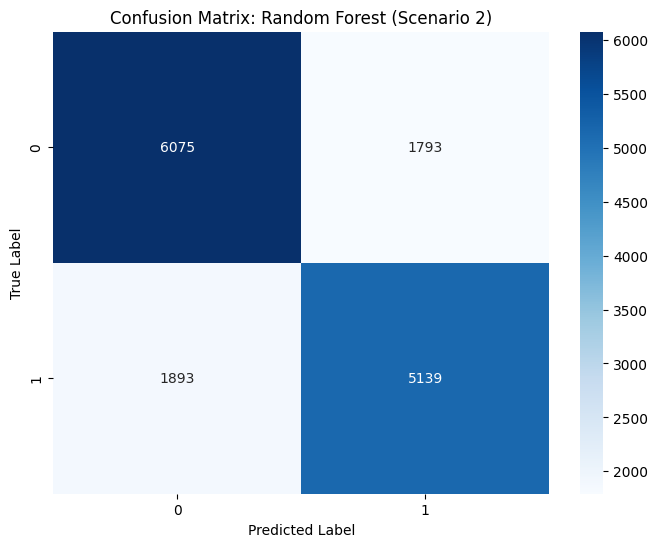

In [114]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Classification Report

In [115]:
report_dict = classification_report(y_test, y_pred_test, 
                                     target_names=['stayed', 'left'], 
                                     output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

display(report_df.style.background_gradient(cmap='viridis', subset=['precision', 'recall', 'f1-score']))

,precision,recall,f1-score,support
stayed,0.762425,0.772115,0.767239,7868.000000
left,0.741344,0.730802,0.736036,7032.000000
accuracy,0.752617,0.752617,0.752617,0.752617
macro avg,0.751885,0.751458,0.751637,14900.000000
weighted avg,0.752476,0.752617,0.752513,14900.000000


### ROC Curve

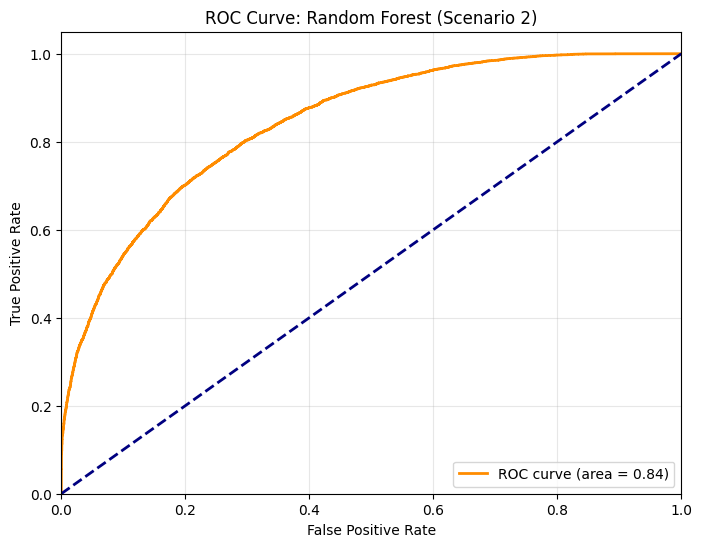

In [116]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve: {best_model_name}')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Precision-Recall Curve

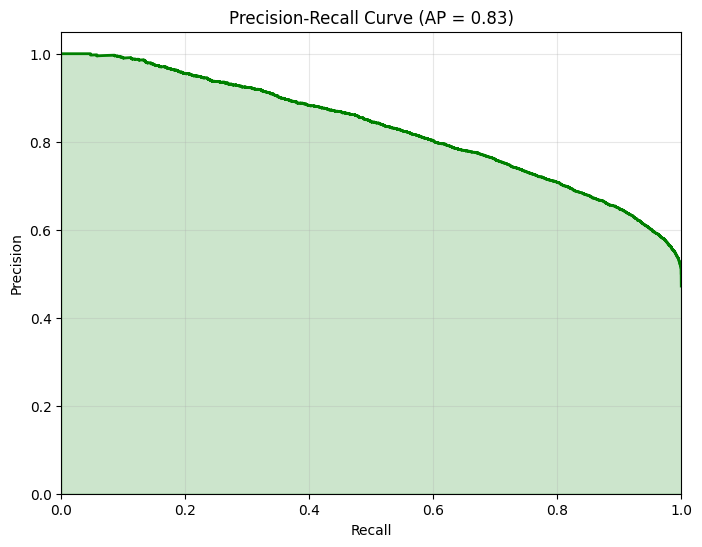

In [117]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
average_precision = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.step(recall, precision, where='post', color='green', lw=2)
plt.fill_between(recall, precision, step='post', alpha=0.2, color='green')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AP = {average_precision:.2f})')
plt.grid(alpha=0.3)
plt.show()

## Probability Distribution Analysis

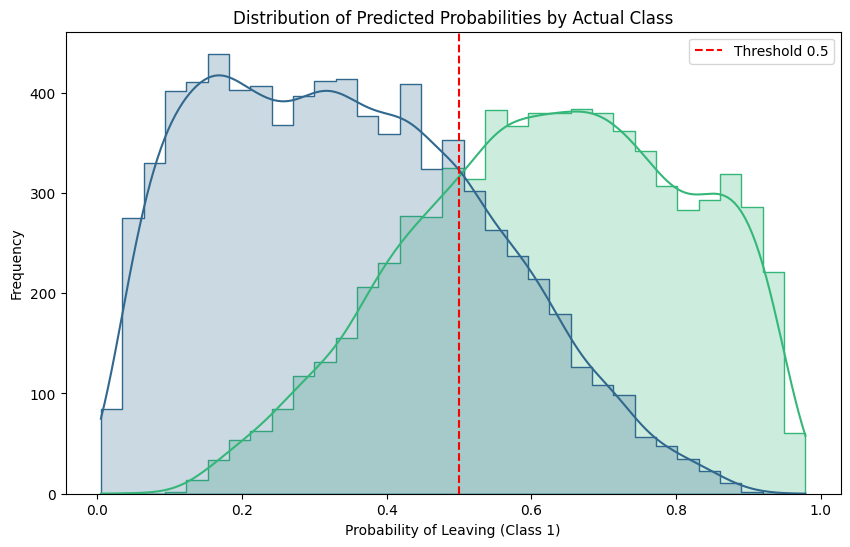

In [118]:
plt.figure(figsize=(10, 6))
sns.histplot(x=y_pred_proba, hue=y_test, element="step", kde=True, palette='viridis')
plt.title('Distribution of Predicted Probabilities by Actual Class')
plt.xlabel('Probability of Leaving (Class 1)')
plt.ylabel('Frequency')
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold 0.5')
plt.legend()
plt.show()

### Error Analysis:

In [119]:
test_results = X_test.copy()
test_results['Actual'] = y_test
test_results['Predicted'] = y_pred_test

In [120]:
fn_employees = test_results[(test_results['Actual'] == 1) & (test_results['Predicted'] == 0)]
tp_employees = test_results[(test_results['Actual'] == 1) & (test_results['Predicted'] == 1)]

print(f"Jumlah False Negatives (Gagal Deteksi): {len(fn_employees)}")
print(f"Jumlah True Positives (Berhasil Deteksi): {len(tp_employees)}")

Jumlah False Negatives (Gagal Deteksi): 1893
Jumlah True Positives (Berhasil Deteksi): 5139


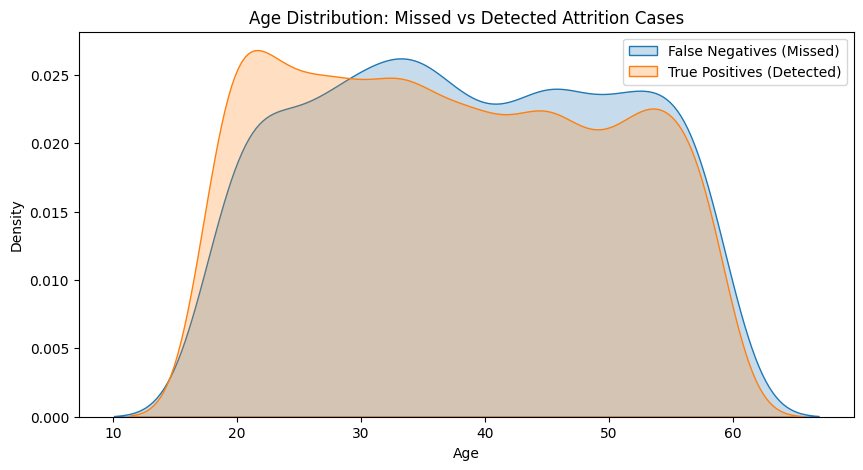

In [121]:
plt.figure(figsize=(10, 5))
sns.kdeplot(fn_employees['Age'], label='False Negatives (Missed)', fill=True)
sns.kdeplot(tp_employees['Age'], label='True Positives (Detected)', fill=True)
plt.title('Age Distribution: Missed vs Detected Attrition Cases')
plt.legend()
plt.show()

## Feature Importance Analysis

In [122]:
importances = best_model.feature_importances_
feature_names = X_train_scaled.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

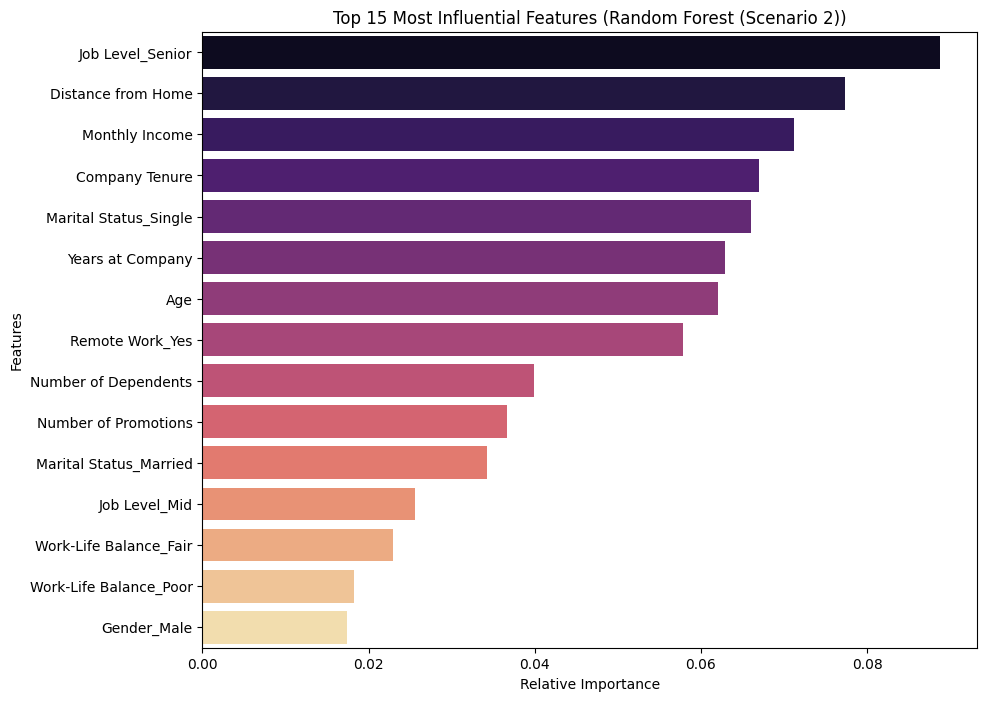

In [123]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title(f'Top 15 Most Influential Features ({best_model_name})')
plt.xlabel('Relative Importance')
plt.ylabel('Features')

plt.show()